In [1]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [2]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

baseline construct D: joint=0.254 bloom=M dRF=0.275 Z200_inv=-0.0119 n_clean=2

most bloom-shifting nudges (−d_post_bloom = earlier):
      screw   val  joint  post_bloom   dRF  Z200_inv  n_clean  d_joint  d_post_bloom  d_dRF  d_Zinv
    k_remin 0.150  0.365           2 0.000    -0.052        3    0.110            -1 -0.275  -0.040
   q10_grow 1.215  0.401           2 0.039    -0.039        4    0.147            -1 -0.236  -0.027
  q10_graze 3.100  0.229           2 0.432    -0.004        2   -0.025            -1  0.157   0.008
  q10_graze 3.720  0.250           2 0.511     0.002        2   -0.004            -1  0.236   0.014
    k_remin 0.125  0.296           2 0.275    -0.019        4    0.041            -1  0.000  -0.007
   mu_scale 1.500  0.306           2 0.354    -0.005        0    0.052            -1  0.079   0.007
        GGE 0.232  0.515           2 0.000    -0.029        0    0.260            -1 -0.275  -0.017
     w_sink 3.750  0.304           2 0.314    -0.016        3    0

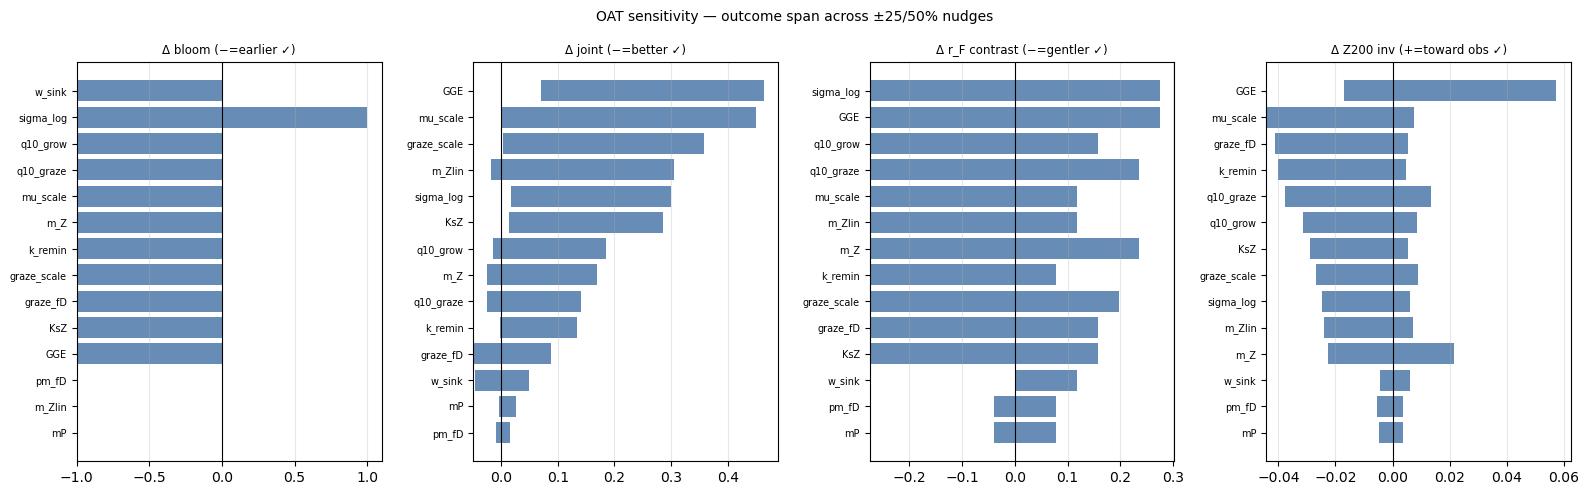

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
import seasonal_scan_harness as ssh

res=ssh.load_results('seasonal_OAT_hplc3h_2026-06-28.pkl'); recs=res.records; OBS=res.obs
obs_m=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
MO=['J','F','M','A','M','J','J','A','S','O','N','D']
TGT=['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR=0.15,100.,0.02,1e-6
CENTER={'GGE':0.31,'mP':0.0015,'m_Z':0.10,'KsZ':0.23,'sigma_log':0.20,'m_Zlin':0.05,
        'k_remin':0.10,'w_sink':5.0,'q10_grow':1.62,'q10_graze':2.48,'mu_scale':1.0,
        'graze_scale':1.0,'graze_fD':0.75,'pm_fD':0.9}
obb={g:int(np.nanargmax(obs_m[g].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(range(1,13)).values))+1 for g in OBS}
def csc(r):
    g=r['group']
    def rms(get,ov): 
        t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']),rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
def bmo(r):
    c=np.asarray(r.get('clim_sumP',[np.nan]*12),float); return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
def flg(r):
    g=r['group']; omn=OBS[g]['mean']; f=''
    if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
    if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
    cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in('pico','nano','micro')]
    if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
    if omn.get('nano') and np.isfinite(r.get('nano',np.nan)) and r['nano']>omn['nano']*(1+CTOL): f+='n'
    if omn.get('micro') and np.isfinite(r.get('micro',np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
    bm=bmo(r); ob=obb[g]
    if not(np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob)<=1): f+='b'
    return f
def screw_of(r):
    for k,cv in CENTER.items():
        if abs(float(r.get(k,cv))-cv) > 1e-9*max(1,abs(cv)): return k,float(r.get(k,cv))
    return 'baseline',0.0
for r in recs: r['_sc']=csc(r); r['_fl']=flg(r); r['_bm']=bmo(r); s=screw_of(r); r['_screw'],r['_val']=s
byc=defaultdict(lambda:{'pre+recovery':[],'post':[]})
for r in recs: byc[(r['_screw'],round(r['_val'],6))][r['group']].append(r)
rows=[]
for (screw,val),d in byc.items():
    P=[(max(p['_sc'],q['_sc']),p['fish'],q['fish'],q.get('Z200',np.nan)-p.get('Z200',np.nan),q['_bm'],
        p['_fl']=='' and q['_fl']=='' and np.isfinite(q.get('Z200',np.nan)-p.get('Z200',np.nan)) and (q.get('Z200',0)-p.get('Z200',0))>0)
       for p in d['pre+recovery'] for q in d['post'] if q['fish']<=p['fish']]
    P=[x for x in P if np.isfinite(x[0])]
    if not P: continue
    bj=min(P,key=lambda x:x[0])
    rows.append(dict(screw=screw,val=round(val,4),joint=bj[0],dRF=bj[1]-bj[2],post_bloom=bj[4],
                     Z200_inv=bj[3],n_clean=sum(x[5] for x in P)))
S=pd.DataFrame(rows); b=S[S.screw=='baseline'].iloc[0]
print(f"baseline construct D: joint={b.joint:.3f} bloom={MO[int(b.post_bloom)-1]} dRF={b.dRF:.3f} Z200_inv={b.Z200_inv:+.4f} n_clean={int(b.n_clean)}")
S['d_joint']=S.joint-b.joint; S['d_post_bloom']=S.post_bloom-b.post_bloom
S['d_dRF']=S.dRF-b.dRF; S['d_Zinv']=S.Z200_inv-b.Z200_inv
sc=S[S.screw!='baseline'].copy()
print("\nmost bloom-shifting nudges (−d_post_bloom = earlier):")
print(sc.sort_values('d_post_bloom')[['screw','val','joint','post_bloom','dRF','Z200_inv','n_clean','d_joint','d_post_bloom','d_dRF','d_Zinv']].round(3).head(15).to_string(index=False))
M=[('d_post_bloom','Δ bloom (−=earlier ✓)'),('d_joint','Δ joint (−=better ✓)'),('d_dRF','Δ r_F contrast (−=gentler ✓)'),('d_Zinv','Δ Z200 inv (+=toward obs ✓)')]
fig,axes=plt.subplots(1,4,figsize=(16,5))
for ax,(m,lab) in zip(axes,M):
    g=sc.groupby('screw')[m].agg(['min','max']); g=g.reindex(g.abs().max(axis=1).sort_values().index); y=np.arange(len(g))
    ax.barh(y,g['max']-g['min'],left=g['min'],color='#4C78A8',alpha=0.85); ax.axvline(0,color='k',lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(g.index,fontsize=7); ax.set_title(lab,fontsize=8.5); ax.grid(axis='x',alpha=0.3)
fig.suptitle('OAT sensitivity — outcome span across ±25/50% nudges',fontsize=10); plt.tight_layout(); plt.show()

In [8]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
res=ssh.load_results('seasonal_OAT_hplc3h_2026-06-28.pkl'); recs=res.records; OBS=res.obs
obs_m=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
MO=['J','F','M','A','M','J','J','A','S','O','N','D']
TGT=['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR=0.15,100.,0.02,1e-6
CENTER={'GGE':0.31,'mP':0.0015,'m_Z':0.10,'KsZ':0.23,'sigma_log':0.20,'m_Zlin':0.05,'k_remin':0.10,
        'w_sink':5.0,'q10_grow':1.62,'q10_graze':2.48,'mu_scale':1.0,'graze_scale':1.0,'graze_fD':0.75,'pm_fD':0.9}
obb={g:int(np.nanargmax(obs_m[g].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(range(1,13)).values))+1 for g in OBS}
def csc(r):
    g=r['group']
    def rms(get,ov): 
        t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']),rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
def bmo(r):
    c=np.asarray(r.get('clim_sumP',[np.nan]*12),float); return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
def flg(r):
    g=r['group']; omn=OBS[g]['mean']; f=''
    if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
    if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
    cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in('pico','nano','micro')]
    if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
    if omn.get('nano') and np.isfinite(r.get('nano',np.nan)) and r['nano']>omn['nano']*(1+CTOL): f+='n'
    if omn.get('micro') and np.isfinite(r.get('micro',np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
    bm=bmo(r); ob=obb[g]
    if not(np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob)<=1): f+='b'
    return f
def screw_of(r):
    for k,cv in CENTER.items():
        if abs(float(r.get(k,cv))-cv)>1e-9*max(1,abs(cv)): return f"{k}={float(r.get(k,cv)):g}"
    return 'baseline'
D=pd.DataFrame([dict(combo=screw_of(r),group=r['group'],rF=r['fish'],score=csc(r),flag=flg(r),bloom=bmo(r),
                     Z200=r.get('Z200',np.nan),mcs=r.get('mcs',np.nan),micro=r.get('micro',np.nan),
                     sumP=r.get('sumP',np.nan),N=r.get('N',np.nan)) for r in recs])

for g in ['pre+recovery','post']:
    sub=D[D.group==g].sort_values('score')
    print(f"\n=== {g}: best-fit single runs (any flag) ===")
    print(sub.head(8).round(3).to_string(index=False))
    cl=sub[sub.flag=='']; print("   best CLEAN: "+(cl.head(3).round(3).to_string(index=False) if len(cl) else 'none'))

oinv=OBS['post']['mean']['Z200']-OBS['pre+recovery']['mean']['Z200']; rows=[]
for combo,d in D.groupby('combo'):
    pre=d[d.group=='pre+recovery']; post=d[d.group=='post']
    for _,p in pre.iterrows():
        for _,q in post.iterrows():
            if q.rF>p.rF: continue
            rows.append(dict(combo=combo,pre_rF=p.rF,post_rF=q.rF,joint=max(p.score,q.score),
                pre_fl=p.flag or '·',post_fl=q.flag or '·',Zdir=q.Z200-p.Z200>0,Z200_inv=q.Z200-p.Z200,
                post_bloom=MO[int(q.bloom)-1] if np.isfinite(q.bloom) else '·'))
JP=pd.DataFrame(rows)
print(f"\n=== within-combo joint pairs (obs Z200 inv target {oinv:+.4f}) ===\ntop 12 by joint (any flag):")
print(JP.sort_values('joint').head(12).round(3).to_string(index=False))
clean=JP[(JP.pre_fl=='·')&(JP.post_fl=='·')&(JP.Zdir)]
print(f"\ntop 12 CLEAN + Zdir-ok ({len(clean)} total):")
print(clean.sort_values('joint').head(12).round(3).to_string(index=False) if len(clean) else 'none')


=== pre+recovery: best-fit single runs (any flag) ===
           combo        group    rF  score flag  bloom  Z200   mcs  micro  sumP     N
  q10_graze=1.24 pre+recovery 0.600  0.125           3 0.029 7.697  0.358 0.860 0.790
      GGE=0.2325 pre+recovery 0.600  0.129           3 0.023 7.616  0.375 0.866 0.798
graze_scale=0.75 pre+recovery 0.600  0.130           3 0.031 7.525  0.360 0.863 0.763
      GGE=0.2325 pre+recovery 0.561  0.132           3 0.024 7.635  0.363 0.877 0.797
  q10_graze=1.24 pre+recovery 0.482  0.137           3 0.031 7.173  0.356 0.834 0.859
      GGE=0.2325 pre+recovery 0.482  0.144           3 0.026 7.133  0.354 0.850 0.834
      GGE=0.2325 pre+recovery 0.443  0.145           3 0.027 7.248  0.353 0.872 0.843
    m_Zlin=0.075 pre+recovery 0.521  0.147           3 0.029 7.139  0.343 0.788 0.994
   best CLEAN:            combo        group  rF  score flag  bloom  Z200   mcs  micro  sumP     N
  q10_graze=1.24 pre+recovery 0.6  0.125           3 0.029 7.697  0.358 

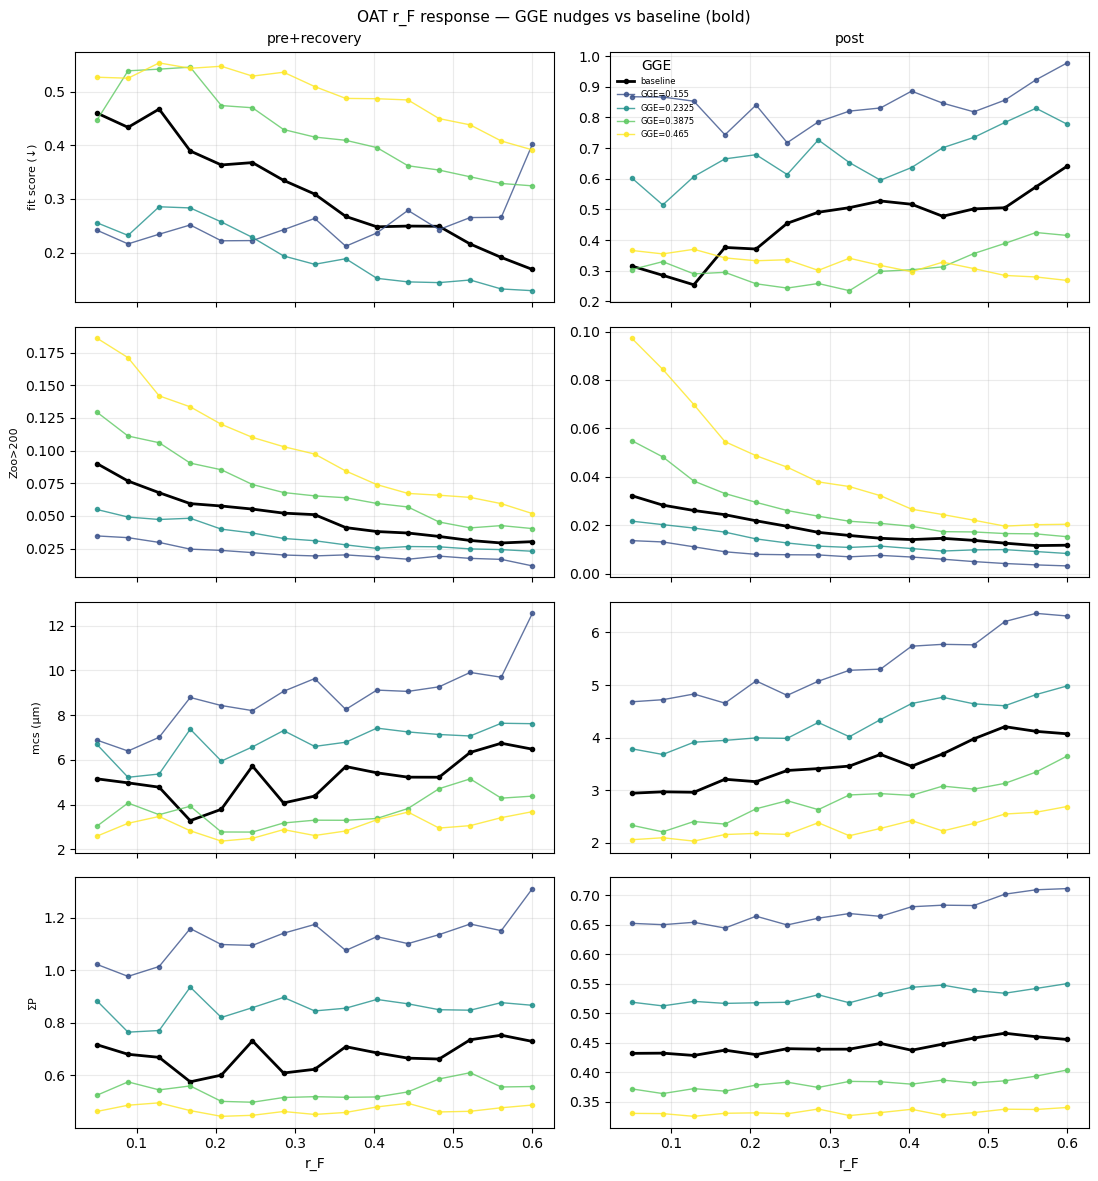

In [28]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
SCREW='GGE'      # ← GGE, m_Z, q10_graze, graze_fD, KsZ, sigma_log, ...
METRICS=[('score','fit score (↓)'),('Z200','Zoo>200'),('mcs','mcs (µm)'),('sumP','ΣP')]
combos=sorted([c for c in D.combo.unique() if c=='baseline' or c.startswith(SCREW+'=')],
              key=lambda c:(c!='baseline', float(c.split('=')[1]) if '=' in c else 0))
col={c:('k' if c=='baseline' else cm.viridis(i/max(1,len(combos)-1))) for i,c in enumerate(combos)}
fig,axes=plt.subplots(len(METRICS),2,figsize=(11,3*len(METRICS)),sharex=True)
for j,g in enumerate(['pre+recovery','post']):
    for i,(m,lab) in enumerate(METRICS):
        ax=axes[i,j]
        for c in combos:
            d=D[(D.combo==c)&(D.group==g)].sort_values('rF')
            ax.plot(d.rF,d[m],'-o',ms=3,lw=2 if c=='baseline' else 1,color=col[c],
                    label=c,alpha=1 if c=='baseline' else 0.8)
        if i==0: ax.set_title(g,fontsize=10)
        if j==0: ax.set_ylabel(lab,fontsize=8)
        ax.grid(alpha=0.25)
axes[-1,0].set_xlabel('r_F'); axes[-1,1].set_xlabel('r_F'); axes[0,1].legend(fontsize=6,frameon=False,title=SCREW)
fig.suptitle(f'OAT r_F response — {SCREW} nudges vs baseline (bold)',fontsize=11); plt.tight_layout(); plt.show()

In [25]:
import numpy as np, seasonal_scan_harness as ssh
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=True)
obs  = ssh.build_obs_targets(['pre+recovery','post'])
spec = ssh.allometry('maranon_ward'); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
FISH = {'pre+recovery':0.5,'post':0.1}; TGT=['mcs','pico','nano','micro','sumP']
def run(g,mz): return ssh.run_one(spec,FORC[g],fish_rate=FISH[g],years=60,spinup=15,
    mP=0.0015,m_Z=mz,grazing={'KsZ':0.23,'sigma_log':0.20},
    iv_overrides={'GrazingRouter':{'gge':0.31}},n_harmonics=3)
def fit(c,g):
    om=obs[g]['mean']; t=[((c.get(k,np.nan)-om[k])/om[k])**2 for k in TGT if om.get(k) and np.isfinite(c.get(k,np.nan))]
    return float(np.sqrt(np.mean(t))) if t else np.nan
oinv = obs['post']['mean']['Z200']-obs['pre+recovery']['mean']['Z200']
print(f"obs Z200 inversion (post−pre) = {oinv:+.4f}\n")
print(f"{'m_Z':>5}{'pre_Z200':>10}{'post_Z200':>10}{'inv':>9}{'pre_fit':>9}{'post_fit':>9}{'pre_mcs':>8}{'post_mcs':>9}{'pre_bl':>7}{'post_bl':>8}")
for mz in (0.10, 0.05):
    cp,cq=run('pre+recovery',mz),run('post',mz)
    print(f"{mz:>5}{cp['Z200']:>10.4f}{cq['Z200']:>10.4f}{cq['Z200']-cp['Z200']:>+9.4f}"
          f"{fit(cp,'pre+recovery'):>9.3f}{fit(cq,'post'):>9.3f}{cp['mcs']:>8.3f}{cq['mcs']:>9.3f}"
          f"{MO[int(np.nanargmax(cp['clim_sumP']))]:>7}{MO[int(np.nanargmax(cq['clim_sumP']))]:>8}")

obs Z200 inversion (post−pre) = +0.0128

  m_Z  pre_Z200 post_Z200      inv  pre_fit post_fit pre_mcs post_mcs pre_bl post_bl
  0.1    0.0329    0.0274  -0.0054    0.214    0.216   5.835    2.860      M       M
 0.05    0.0383    0.0324  -0.0059    0.290    0.256   4.664    2.533      F       M


obs post: bloom=F (median ΣP peak 1.286)


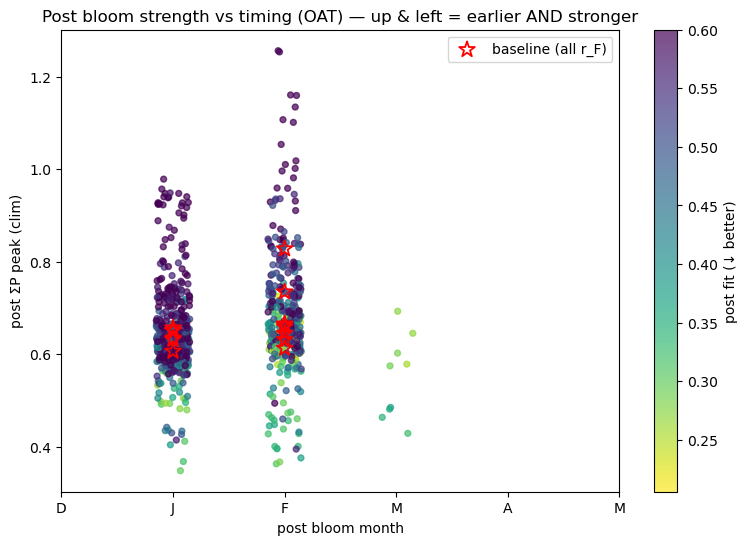


baseline post @r_F≈0.1: bloom=M peak=0.663 amp=0.370 fit=0.285

screws EARLIER than baseline with peak≥baseline & fit≤base+0.05 (@r_F≈0.1): 1
        screw    rF  bloom  peak   amp   fit
graze_fD=0.45 0.089      2 0.676 0.319 0.317


In [52]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
res=ssh.load_results('seasonal_OAT_hplc3h_2026-06-28.pkl'); recs=res.records; OBS=res.obs
obs_m=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
CENTER={'GGE':0.31,'mP':0.0015,'m_Z':0.10,'KsZ':0.23,'sigma_log':0.20,'m_Zlin':0.05,'k_remin':0.10,
        'w_sink':5.0,'q10_grow':1.62,'q10_graze':2.48,'mu_scale':1.0,'graze_scale':1.0,'graze_fD':0.75,'pm_fD':0.9}
def csc(r):
    g=r['group']
    def rms(get,ov): 
        t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']),rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
def screw_of(r):
    for k,cv in CENTER.items():
        if abs(float(r.get(k,cv))-cv)>1e-9*max(1,abs(cv)): return f"{k}={float(r.get(k,cv)):g}"
    return 'baseline'
ob=obs_m['post'].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(range(1,13)).values
print(f"obs post: bloom={MO[int(np.nanargmax(ob))]} (median ΣP peak {np.nanmax(ob):.3f})")

rows=[]
for r in recs:
    if r['group']!='post': continue
    c=np.asarray(r.get('clim_sumP',[np.nan]*12),float)
    if not np.isfinite(c).any(): continue
    rows.append(dict(screw=screw_of(r),rF=r['fish'],bloom=int(np.nanargmax(c))+1,
                     peak=float(np.nanmax(c)),amp=float(np.nanmax(c)-np.nanmin(c)),fit=csc(r)))
D=pd.DataFrame(rows)

fig,ax=plt.subplots(figsize=(9,6))
sc=ax.scatter(D.bloom+np.random.uniform(-.15,.15,len(D)),D.peak,c=D.fit,cmap='viridis_r',vmax=0.6,s=18,alpha=.7)
bb=D[D.screw=='baseline']; ax.scatter(bb.bloom,bb.peak,marker='*',s=140,edgecolor='r',facecolor='none',lw=1.3,label='baseline (all r_F)')
plt.colorbar(sc,label='post fit (↓ better)'); ax.set_xlabel('post bloom month'); ax.set_ylabel('post ΣP peak (clim)')
ax.set_xticks(range(1,7)); ax.set_xticklabels([MO[m-1] for m in range(6)]); ax.legend()
ax.set_title('Post bloom strength vs timing (OAT) — up & left = earlier AND stronger'); plt.show()

D01=D[(D.rF-0.1).abs()<0.02]; b0=D01[D01.screw=='baseline'].iloc[0]
print(f"\nbaseline post @r_F≈0.1: bloom={MO[int(b0.bloom)-1]} peak={b0.peak:.3f} amp={b0.amp:.3f} fit={b0.fit:.3f}")
better=D01[(D01.bloom<b0.bloom)&(D01.peak>=b0.peak)&(D01.fit<=b0.fit+0.05)]
print(f"\nscrews EARLIER than baseline with peak≥baseline & fit≤base+0.05 (@r_F≈0.1): {len(better)}")
print(better.sort_values(['bloom','fit']).round(3).to_string(index=False) if len(better) else "  none — strength/timing tradeoff holds → settle forcing + keep baseline")

baseline post @r_F≈0.089:  ΣP_med=0.393  maxP=0.663  bloom=M  fit=0.285


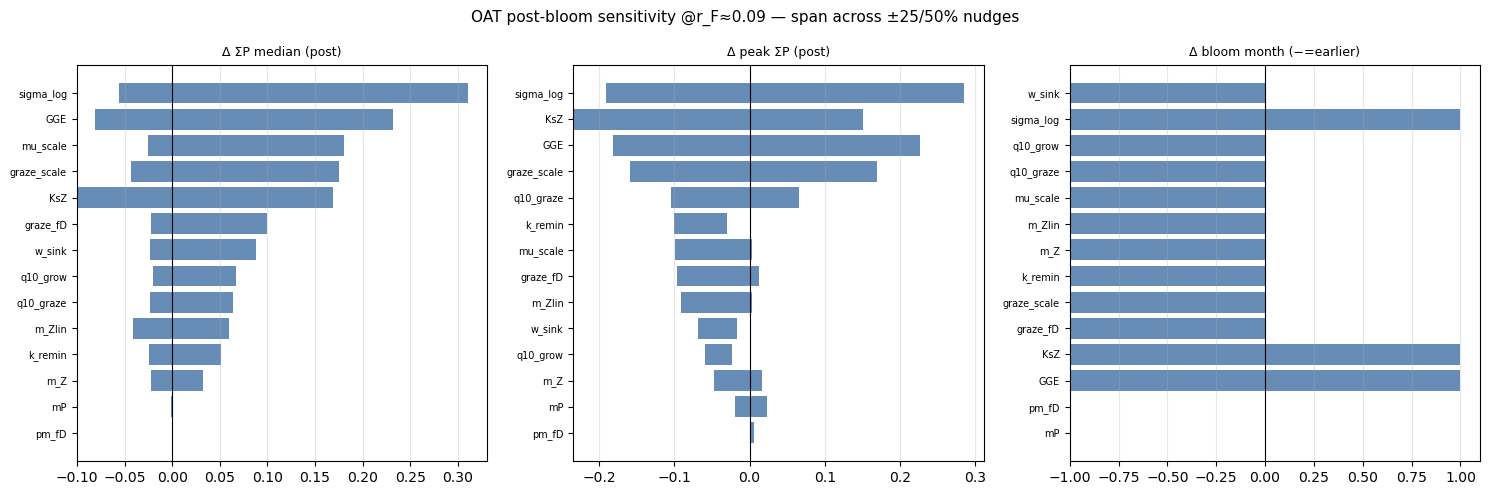


strongest-peak nudges (post @r_F≈0.1):
      screw   val  sumP  maxP  bloom   fit  d_maxP  d_bloom
  sigma_log 0.100 0.703 0.948      2 0.762   0.285       -1
        GGE 0.155 0.625 0.889      2 0.867   0.226       -1
graze_scale 0.500 0.568 0.832      3 0.688   0.169        0
        KsZ 0.345 0.562 0.814      2 0.602   0.151       -1
  q10_graze 1.240 0.457 0.729      3 0.400   0.066        0
  sigma_log 0.150 0.491 0.725      2 0.469   0.062       -1
        KsZ 0.288 0.474 0.718      2 0.416   0.055       -1
        GGE 0.232 0.478 0.718      2 0.515   0.055       -1
graze_scale 0.750 0.447 0.703      3 0.381   0.040        0
  q10_graze 1.860 0.412 0.687      3 0.257   0.024        0

earliest-bloom nudges:
      screw   val  sumP  maxP  bloom   fit  d_bloom
        m_Z 0.150 0.426 0.615      2 0.536       -1
   graze_fD 0.450 0.492 0.676      2 0.317       -1
graze_scale 1.500 0.350 0.505      2 0.264       -1
graze_scale 1.250 0.362 0.561      2 0.252       -1
   mu_scale 1.50

In [55]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
res=ssh.load_results('seasonal_OAT_hplc3h_2026-06-28.pkl'); recs=res.records; OBS=res.obs
MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
CENTER={'GGE':0.31,'mP':0.0015,'m_Z':0.10,'KsZ':0.23,'sigma_log':0.20,'m_Zlin':0.05,'k_remin':0.10,
        'w_sink':5.0,'q10_grow':1.62,'q10_graze':2.48,'mu_scale':1.0,'graze_scale':1.0,'graze_fD':0.75,'pm_fD':0.9}
def scr(r):
    for k,cv in CENTER.items():
        if abs(float(r.get(k,cv))-cv)>1e-9*max(1,abs(cv)): return k,float(r.get(k,cv))
    return 'baseline',np.nan
def csc(r):
    g=r['group']
    def rms(get,ov): 
        t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']),rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
rows=[]
for r in recs:
    if r['group']!='post': continue
    c=np.asarray(r.get('clim_sumP',[np.nan]*12),float)
    if not np.isfinite(c).any(): continue
    s,v=scr(r)
    rows.append(dict(screw=s,val=v,rF=r['fish'],sumP=r.get('sumP_med',r.get('sumP',np.nan)),
                     maxP=float(np.nanmax(c)),bloom=int(np.nanargmax(c))+1,fit=csc(r)))
D=pd.DataFrame(rows); D01=D[(D.rF-0.1).abs()<0.025]; b=D01[D01.screw=='baseline'].iloc[0]
print(f"baseline post @r_F≈{b.rF:.3f}:  ΣP_med={b.sumP:.3f}  maxP={b.maxP:.3f}  bloom={MO[int(b.bloom)-1]}  fit={b.fit:.3f}")
for c in ['sumP','maxP','bloom']: D01['d_'+c]=D01[c]-b[c]
sc=D01[D01.screw!='baseline']
M=[('d_sumP','Δ ΣP median (post)'),('d_maxP','Δ peak ΣP (post)'),('d_bloom','Δ bloom month (−=earlier)')]
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,(m,lab) in zip(axes,M):
    g=sc.groupby('screw')[m].agg(['min','max']); g=g.reindex(g.abs().max(axis=1).sort_values().index)
    y=np.arange(len(g)); ax.barh(y,g['max']-g['min'],left=g['min'],color='#4C78A8',alpha=.85)
    ax.axvline(0,color='k',lw=.8); ax.set_yticks(y); ax.set_yticklabels(g.index,fontsize=7); ax.set_title(lab,fontsize=9); ax.grid(axis='x',alpha=.3)
fig.suptitle(f'OAT post-bloom sensitivity @r_F≈{b.rF:.2f} — span across ±25/50% nudges',fontsize=11); plt.tight_layout(); plt.show()
print("\nstrongest-peak nudges (post @r_F≈0.1):")
print(sc.sort_values('maxP',ascending=False).head(10)[['screw','val','sumP','maxP','bloom','fit','d_maxP','d_bloom']].round(3).to_string(index=False))
print("\nearliest-bloom nudges:")
print(sc[sc.d_bloom<0].sort_values('bloom')[['screw','val','sumP','maxP','bloom','fit','d_bloom']].round(3).round(3).to_string(index=False) if (sc.d_bloom<0).any() else "  none earlier than baseline")

In [29]:
import os
for v in ('OMP','OPENBLAS','MKL','VECLIB','NUMEXPR'): os.environ[f'{v}_NUM_THREADS']='1'
import importlib, numpy as np, seasonal_scan_harness as ssh; importlib.reload(ssh)
FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=True)
BASE = {'GGE':0.31,'mP':0.0015,'KsZ':0.23,'sigma_log':0.20}
combos=[{**BASE,'m_Z':mz,'w_sink':ws} for mz in (0.05,0.10) for ws in (2.5,5.0)]
print(f"m_Z×w_sink scan: {len(combos)} combos × 2 eras × 20 r_F = {len(combos)*40} runs")
res = ssh.run_seasonal_scan(constructs=['maranon_ward'], groups=['pre+recovery','post'],
    fish_rates=list(np.linspace(0.05,0.6,20)), param_combos=combos, years=60, spinup=15,
    n_harmonics=3, forcings=FORC,
    save_path='seasonal_mZ_wsink_2026-06-28.pkl', processes=None, maxtasksperchild=1)
print("done:", len(res.records))

m_Z×w_sink scan: 4 combos × 2 eras × 20 r_F = 160 runs
[seasonal scan] 160 runs: ['maranon_ward'] x ['pre+recovery', 'post'] x fish=[np.float64(0.05), np.float64(0.07894736842105263), np.float64(0.10789473684210527), np.float64(0.13684210526315788), np.float64(0.16578947368421051), np.float64(0.19473684210526315), np.float64(0.22368421052631576), np.float64(0.2526315789473684), np.float64(0.28157894736842104), np.float64(0.31052631578947365), np.float64(0.33947368421052626), np.float64(0.36842105263157887), np.float64(0.39736842105263154), np.float64(0.42631578947368415), np.float64(0.45526315789473676), np.float64(0.4842105263157894), np.float64(0.513157894736842), np.float64(0.5421052631578946), np.float64(0.5710526315789474), np.float64(0.6)] x params['GGE', 'KsZ', 'mP', 'm_Z', 'sigma_log', 'w_sink'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001} | fourier n_harm=3 | processes=cpu-1
--- run_par

obs Z200 inversion target = +0.0128  (★ = committed 0.5/0.1)



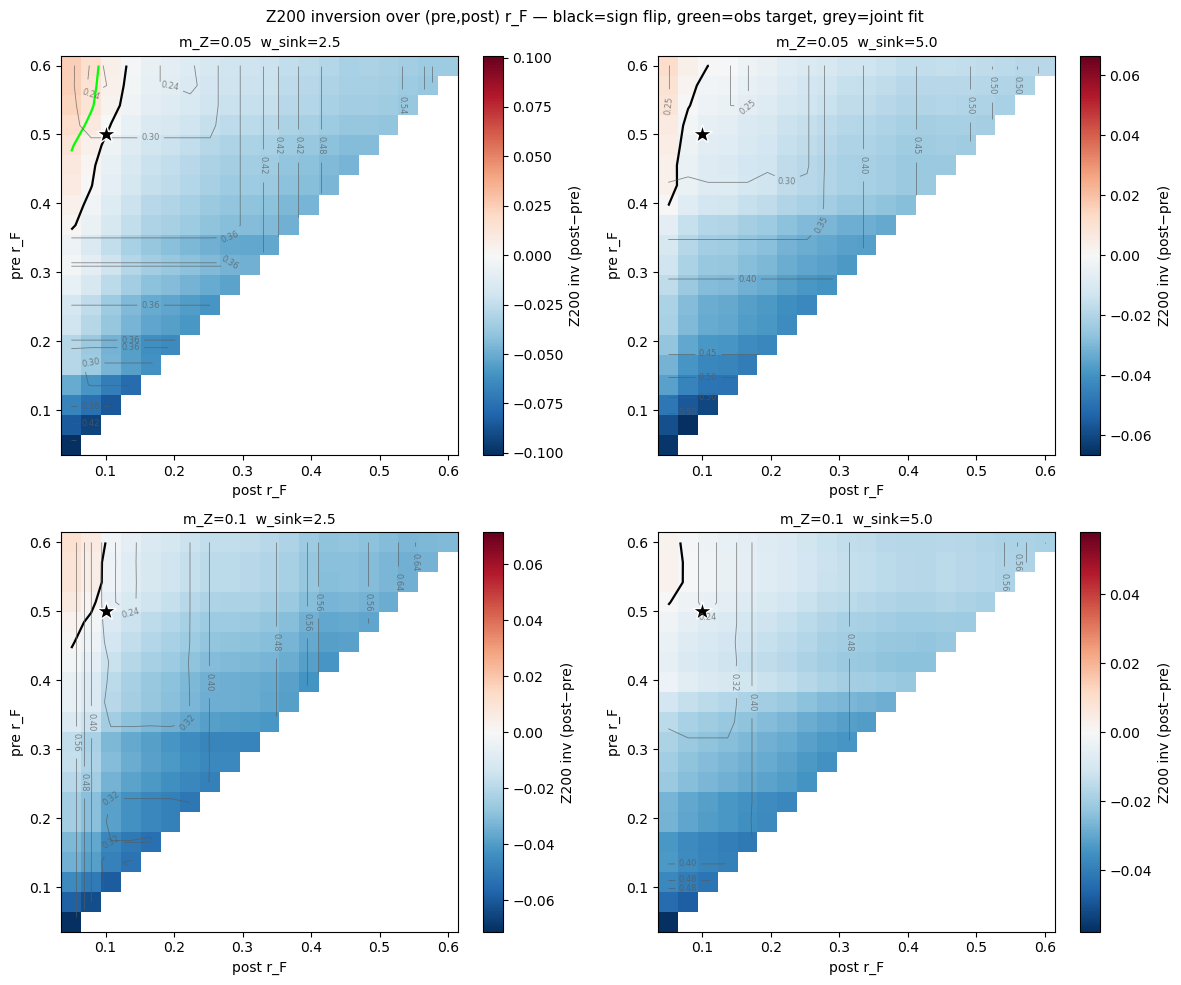

  m_Z w_sink  inv@.5/.1 fit@.5/.1  n_pos              best clean+Zdir pair
 0.05    2.5    -0.0003     0.282     19                              none
 0.05    5.0    -0.0061     0.274     12j=0.248 pre0.60/post0.05 inv+0.0122
  0.1    2.5    -0.0070     0.248     10j=0.401 pre0.51/post0.08 inv+0.0020
  0.1    5.0    -0.0047     0.219      4j=0.316 pre0.54/post0.05 inv+0.0023


In [30]:
import numpy as np, matplotlib.pyplot as plt, seasonal_scan_harness as ssh
res=ssh.load_results('seasonal_mZ_wsink_2026-06-28.pkl'); recs=res.records; OBS=res.obs
obs_m=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
TGT=['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR=0.15,100.,0.02,1e-6
obb={g:int(np.nanargmax(obs_m[g].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(range(1,13)).values))+1 for g in OBS}
oinv=OBS['post']['mean']['Z200']-OBS['pre+recovery']['mean']['Z200']
def csc(r):
    g=r['group']
    def rms(get,ov): 
        t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']),rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
def flg(r):
    g=r['group']; omn=OBS[g]['mean']; f=''
    if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
    if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
    cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in('pico','nano','micro')]
    if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
    if omn.get('nano') and np.isfinite(r.get('nano',np.nan)) and r['nano']>omn['nano']*(1+CTOL): f+='n'
    if omn.get('micro') and np.isfinite(r.get('micro',np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
    bm=np.asarray(r.get('clim_sumP',[np.nan]*12),float); bmo=int(np.nanargmax(bm))+1 if np.isfinite(bm).any() else np.nan
    if not(np.isfinite(bmo) and abs(bmo-obb[g])<=1): f+='b'
    return f
for r in recs: r['_sc']=csc(r); r['_fl']=flg(r)
key=lambda r:(round(r.get('m_Z',0.10),4),round(r.get('w_sink',5.0),4)); combos=sorted({key(r) for r in recs})
print(f"obs Z200 inversion target = {oinv:+.4f}  (★ = committed 0.5/0.1)\n")
fig,axes=plt.subplots(2,2,figsize=(12,10)); axes=axes.ravel()
for ax,(mz,ws) in zip(axes,combos):
    sub=[r for r in recs if key(r)==(mz,ws)]; P={(r['group'],round(r['fish'],4)):r for r in sub}
    pre=sorted({r['fish'] for r in sub if r['group']=='pre+recovery'}); post=sorted({r['fish'] for r in sub if r['group']=='post'})
    INV=np.full((len(pre),len(post)),np.nan); JNT=np.full_like(INV,np.nan)
    for i,pf in enumerate(pre):
        for j,qf in enumerate(post):
            if qf>pf: continue
            a,b=P.get(('pre+recovery',round(pf,4))),P.get(('post',round(qf,4)))
            if a and b: INV[i,j]=b.get('Z200',np.nan)-a.get('Z200',np.nan); JNT[i,j]=max(a['_sc'],b['_sc'])
    vlim=np.nanmax(np.abs(INV))
    im=ax.pcolormesh(post,pre,INV,cmap='RdBu_r',vmin=-vlim,vmax=vlim,shading='auto')
    ax.contour(post,pre,INV,levels=[0],colors='k',linewidths=1.6)
    if np.nanmax(INV)>=oinv: ax.contour(post,pre,INV,levels=[oinv],colors='lime',linewidths=1.6)
    cs=ax.contour(post,pre,JNT,levels=6,colors='0.35',linewidths=0.6,alpha=0.7); ax.clabel(cs,fontsize=6,fmt='%.2f')
    ax.plot(0.1,0.5,'k*',ms=15,mec='w',mew=1)
    ax.set_xlabel('post r_F'); ax.set_ylabel('pre r_F'); ax.set_title(f'm_Z={mz}  w_sink={ws}',fontsize=10)
    plt.colorbar(im,ax=ax,label='Z200 inv (post−pre)')
fig.suptitle('Z200 inversion over (pre,post) r_F — black=sign flip, green=obs target, grey=joint fit',fontsize=11)
plt.tight_layout(); plt.show()
print(f"{'m_Z':>5}{'w_sink':>7}{'inv@.5/.1':>11}{'fit@.5/.1':>10}{'n_pos':>7}{'best clean+Zdir pair':>34}")
for mz,ws in combos:
    sub=[r for r in recs if key(r)==(mz,ws)]; P={(r['group'],round(r['fish'],4)):r for r in sub}
    pre=sorted({r['fish'] for r in sub if r['group']=='pre+recovery'}); post=sorted({r['fish'] for r in sub if r['group']=='post'})
    pf0=min(pre,key=lambda x:abs(x-0.5)); qf0=min(post,key=lambda x:abs(x-0.1))
    a0,b0=P[('pre+recovery',round(pf0,4))],P[('post',round(qf0,4))]
    pairs=[(max(P[('pre+recovery',round(pf,4))]['_sc'],P[('post',round(qf,4))]['_sc']),pf,qf,
            P[('post',round(qf,4))].get('Z200',np.nan)-P[('pre+recovery',round(pf,4))].get('Z200',np.nan),
            P[('pre+recovery',round(pf,4))]['_fl']=='' and P[('post',round(qf,4))]['_fl']=='')
           for pf in pre for qf in post if qf<=pf]
    npos=sum(1 for p in pairs if np.isfinite(p[3]) and p[3]>0)
    cz=sorted([p for p in pairs if p[4] and np.isfinite(p[3]) and p[3]>0],key=lambda x:x[0])
    best=f"j={cz[0][0]:.3f} pre{cz[0][1]:.2f}/post{cz[0][2]:.2f} inv{cz[0][3]:+.4f}" if cz else "none"
    print(f"{mz:>5}{ws:>7}{b0.get('Z200',np.nan)-a0.get('Z200',np.nan):>+11.4f}{max(a0['_sc'],b0['_sc']):>10.3f}{npos:>7}{best:>34}")

In [45]:
import numpy as np, seasonal_scan_harness as ssh
res=ssh.load_results('seasonal_mZ_wsink_2026-06-28.pkl'); recs=res.records; OBS=res.obs
key=lambda r:(round(r.get('m_Z',0.1),4),round(r.get('w_sink',5.0),4))
om=OBS['post']['mean']['Z200']-OBS['pre+recovery']['mean']['Z200']
od=OBS['post']['med']['Z200'] -OBS['pre+recovery']['med']['Z200']
print(f"obs Z200 inversion:  MEAN {om:+.4f}   MEDIAN {od:+.4f}\n")
print(f"{'m_Z':>5}{'w_sink':>7}{'inv_MEAN@.5/.1':>15}{'inv_MED@.5/.1':>14}{'npos_mean':>11}{'npos_med':>10}")
for mz,ws in sorted({key(r) for r in recs}):
    sub=[r for r in recs if key(r)==(mz,ws)]; P={(r['group'],round(r['fish'],4)):r for r in sub}
    pre=sorted({r['fish'] for r in sub if r['group']=='pre+recovery'}); post=sorted({r['fish'] for r in sub if r['group']=='post'})
    pf=min(pre,key=lambda x:abs(x-0.5)); qf=min(post,key=lambda x:abs(x-0.1))
    a,b=P[('pre+recovery',round(pf,4))],P[('post',round(qf,4))]
    im=b['Z200']-a['Z200']; imd=b.get('Z200_med',np.nan)-a.get('Z200_med',np.nan)
    npm=sum(1 for p_ in pre for q_ in post if q_<=p_ and P[('post',round(q_,4))]['Z200']-P[('pre+recovery',round(p_,4))]['Z200']>0)
    npd=sum(1 for p_ in pre for q_ in post if q_<=p_ and P[('post',round(q_,4))].get('Z200_med',np.nan)-P[('pre+recovery',round(p_,4))].get('Z200_med',np.nan)>0)
    print(f"{mz:>5}{ws:>7}{im:>+15.4f}{imd:>+14.4f}{npm:>11}{npd:>10}")

obs Z200 inversion:  MEAN +0.0128   MEDIAN +0.0035

  m_Z w_sink inv_MEAN@.5/.1 inv_MED@.5/.1  npos_mean  npos_med
 0.05    2.5        -0.0003       +0.0026         19        19
 0.05    5.0        -0.0061       +0.0019         12        33
  0.1    2.5        -0.0070       -0.0020         10        13
  0.1    5.0        -0.0047       +0.0031          4        36


In [43]:
import numpy as np, seasonal_scan_harness as ssh
# ── pick the run to inspect (feeds the Fig-4 overview cell below) ──
M_Z, W_SINK     = 0.1, 5.0
FISH            = {'pre+recovery': 0.5, 'post': 0.1}      # ← committed alt: {'pre+recovery':0.5,'post':0.1}, M_Z=0.1
HPLC_COINCIDENT = False                                      # ← flip to False for all-cruise forcing
N_HARM = 3
ERAS = ['pre+recovery','post']
FORC = ssh.build_forcings(ERAS, hplc_coincident=HPLC_COINCIDENT)
spec = ssh.allometry('maranon_ward')
runs = {g: ssh.run_one(spec, FORC[g], fish_rate=FISH[g], years=60, spinup=15,
                       mP=0.0015, m_Z=M_Z, grazing={'KsZ':0.23,'sigma_log':0.20},
                       iv_overrides={'GrazingRouter':{'gge':0.31},'DetritusSink':{'w_sink':W_SINK}},
                       n_harmonics=N_HARM, return_traj=True)[1] for g in ERAS}
PICKLES=[f"m_Z={M_Z} w_sink={W_SINK} {'hplc' if HPLC_COINCIDENT else 'all-cruise'}DOY  {FISH['pre+recovery']:.2f}/{FISH['post']:.2f}"]; PICKLE_IDX=0
for g in ERAS:
    r=runs[g]; k=r['t']>=15*365
    print(f"{g:<14} mcs̄={np.nanmean(r['mcs'][k]):5.2f}  ΣP̄={np.nanmean(r['sumP'][k]):.3f}  ΣP_max={np.nanmax(r['sumP'][k]):5.2f}  Z200̄={np.nanmean(r['Z200'][k]):.4f}")
kp,kq=runs['pre+recovery']['t']>=15*365, runs['post']['t']>=15*365
print(f"Z200 inversion (post−pre) = {np.nanmean(runs['post']['Z200'][kq])-np.nanmean(runs['pre+recovery']['Z200'][kp]):+.4f}  | obs +0.0128")

pre+recovery   mcs̄= 6.67  ΣP̄=0.767  ΣP_max= 4.24  Z200̄=0.0365
post           mcs̄= 3.23  ΣP̄=0.472  ΣP_max= 1.22  Z200̄=0.0366
Z200 inversion (post−pre) = +0.0000  | obs +0.0128


In [53]:
import numpy as np, seasonal_scan_harness as ssh
# ── flag-hit run to inspect (feeds the Fig-4 overview cell below) ──
M_Z, W_SINK, GRAZE_FD = 0.10, 5.0, 0.45      # graze_fD=0.45 = the flag-hit; baseline = 0.75
FISH            = {'pre+recovery': 0.5, 'post': 0.1}   # OAT grid point was post 0.089 ≈ 0.1
HPLC_COINCIDENT = True                         # OAT (where the hit was found) used hplc-coincident
N_HARM = 3
ERAS = ['pre+recovery','post']
FORC = ssh.build_forcings(ERAS, hplc_coincident=HPLC_COINCIDENT)
spec = ssh.allometry('maranon_ward')
runs = {g: ssh.run_one(spec, FORC[g], fish_rate=FISH[g], years=60, spinup=15,
                       mP=0.0015, m_Z=M_Z, grazing={'KsZ':0.23,'sigma_log':0.20},
                       iv_overrides={'GrazingRouter':{'gge':0.31,'frac_D':GRAZE_FD},'DetritusSink':{'w_sink':W_SINK}},
                       n_harmonics=N_HARM, return_traj=True)[1] for g in ERAS}
PICKLES=[f"graze_fD={GRAZE_FD} m_Z={M_Z} {'hplc' if HPLC_COINCIDENT else 'all-cruise'}DOY {FISH['pre+recovery']:.2f}/{FISH['post']:.2f}"]; PICKLE_IDX=0
for g in ERAS:
    r=runs[g]; k=r['t']>=15*365
    print(f"{g:<14} mcs̄={np.nanmean(r['mcs'][k]):5.2f}  ΣP̄={np.nanmean(r['sumP'][k]):.3f}  ΣP_max={np.nanmax(r['sumP'][k]):5.2f}  "
          f"Z200̄={np.nanmean(r['Z200'][k]):.4f}  Z200_med={np.nanmedian(r['Z200'][k]):.4f}")
kp,kq=runs['pre+recovery']['t']>=15*365, runs['post']['t']>=15*365
print(f"Z200 inv MEAN   = {np.nanmean(runs['post']['Z200'][kq])-np.nanmean(runs['pre+recovery']['Z200'][kp]):+.4f}  | obs mean   +0.0128")
print(f"Z200 inv MEDIAN = {np.nanmedian(runs['post']['Z200'][kq])-np.nanmedian(runs['pre+recovery']['Z200'][kp]):+.4f}  | obs median +0.0035")

pre+recovery   mcs̄= 5.47  ΣP̄=0.753  ΣP_max= 3.87  Z200̄=0.0633  Z200_med=0.0511
post           mcs̄= 2.78  ΣP̄=0.492  ΣP_max= 0.77  Z200̄=0.0502  Z200_med=0.0430
Z200 inv MEAN   = -0.0132  | obs mean   +0.0128
Z200 inv MEDIAN = -0.0080  | obs median +0.0035


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_30767/3092898766.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]} | pre_rF={FISH['pre+recovery']:.3f} post_rF={FISH['post']:.3f}",fontsize=10); plt.tight_layout(); plt.show()


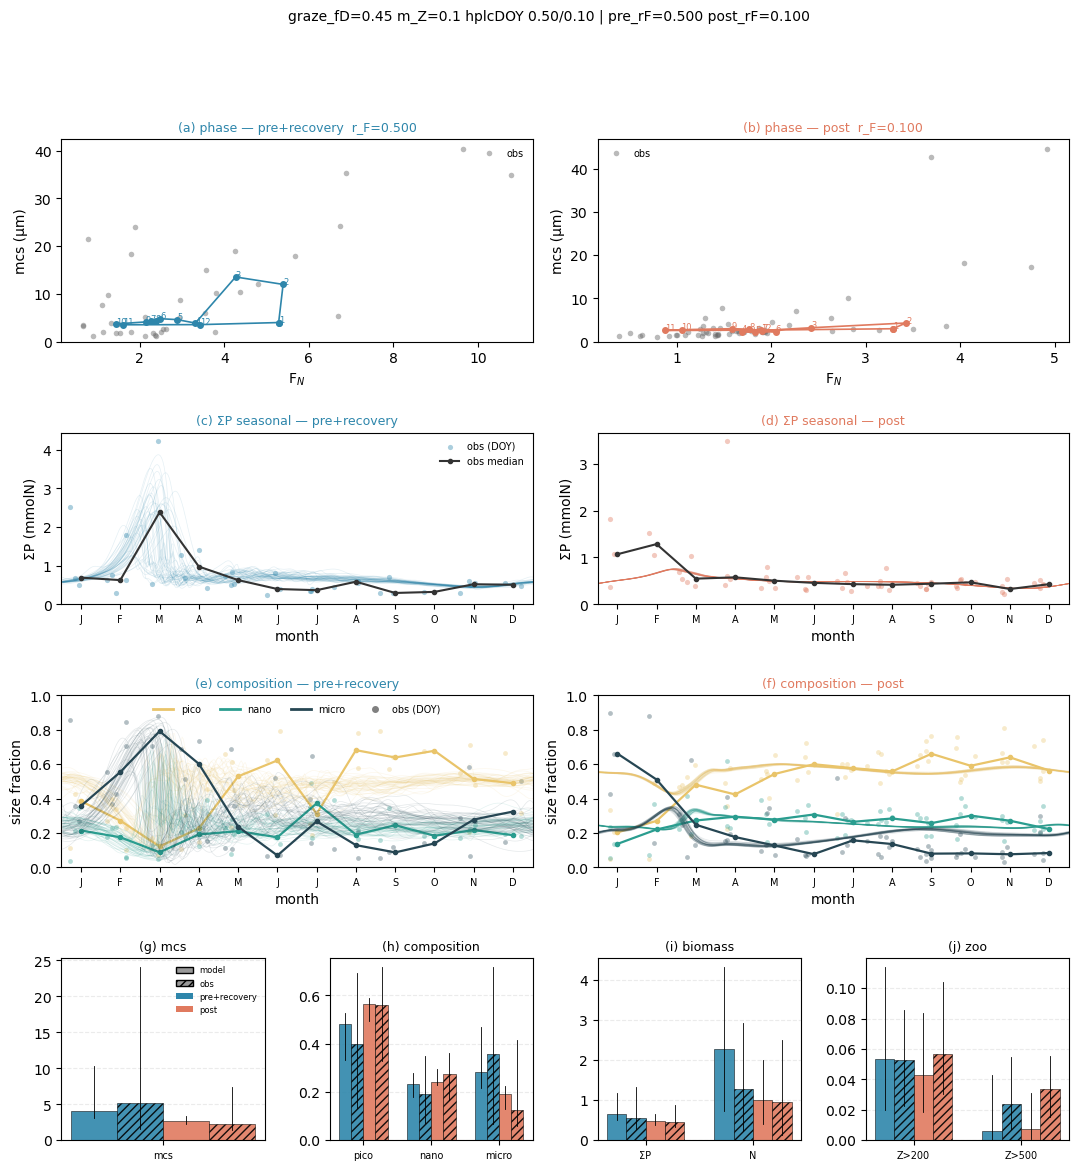

In [54]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(doy): return np.interp(np.asarray(doy,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):                                  # obs x at cruise DOY, mo fallback
    d=df.get(col, pd.Series(np.nan,index=df.index)) if hasattr(df,'get') else df[col]
    return np.where(np.isfinite(d), doy_to_mo(d), df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=0.9,hatch=h,edgecolor='k',lw=0.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=0.6,zorder=4)
import pandas as pd
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,0.85,0.85,0.9],hspace=0.5,wspace=0.32)
# Row0 phase (FN–mcs; no time axis → no DOY)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=0.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
# Row1 ΣP seasonal (obs at doy_hplc)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=0.12,lw=0.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=0.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
# Row2 composition seasonal (obs at doy_hplc)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=0.12,lw=0.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=0.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
# Row3 bars
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-0.5*W,('post','m'):0.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=0.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]} | pre_rF={FISH['pre+recovery']:.3f} post_rF={FISH['post']:.3f}",fontsize=10); plt.tight_layout(); plt.show()

era           var   pt_min  pt_max 2h_over% 3h_over% 4h_over%  4h_min
pre+recovery  fn     1.450   5.711     -6.0      0.3      8.3   1.317
pre+recovery  de    30.093  53.793      0.1      1.4     -0.2  28.193
pre+recovery  t     22.385  25.920      1.4      0.4      0.1  22.501
post          fn     0.753   4.802    -13.8     -7.8     -7.4   0.725
post          de    33.514  56.394     -1.6     -3.5     -0.1  32.089
post          t     22.859  27.238     -1.1     -1.1     -1.4  22.717


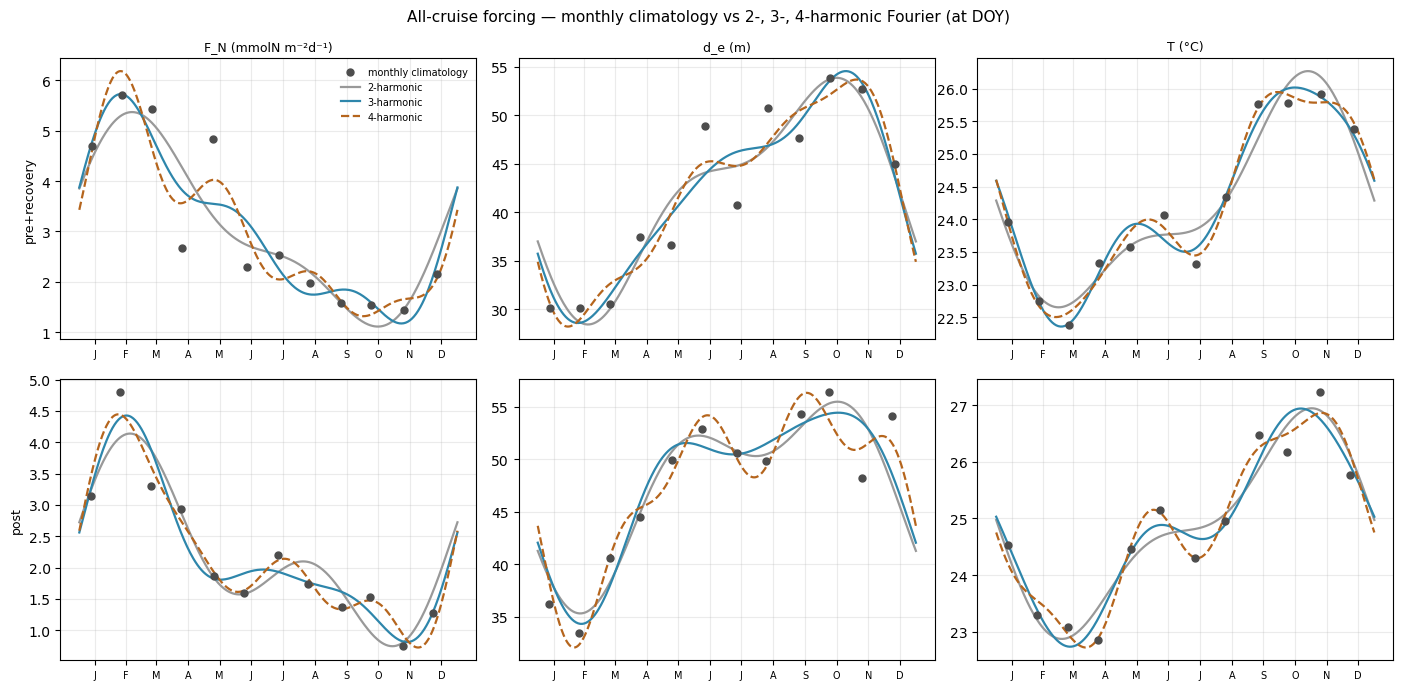

In [51]:
import numpy as np, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func, _MID_MONTH_DOY
PERIOD=365.0; MO=['J','F','M','A','M','J','J','A','S','O','N','D']
HARM=[2,3,4]; HCOL={2:'0.6',3:'#2E86AB',4:'#B5651D'}; HLS={2:'-',3:'-',4:'--'}

FORC = ssh.build_forcings(['pre+recovery','post'], hplc_coincident=False)   # all-cruise
ERAS=['pre+recovery','post']; VARS=[('fn','F_N (mmolN m⁻²d⁻¹)'),('de','d_e (m)'),('t','T (°C)')]
tt=np.linspace(0,365,366)

fig,axes=plt.subplots(len(ERAS),3,figsize=(14,7))
print(f"{'era':<14}{'var':<4}{'pt_min':>8}{'pt_max':>8}" + "".join(f"{str(h)+'h_over%':>9}" for h in HARM) + f"{'4h_min':>8}")
for i,era in enumerate(ERAS):
    F=FORC[era]; doy=np.asarray(F['doy'],float); doy=np.where(np.isfinite(doy),doy,_MID_MONTH_DOY)
    for j,(k,lab) in enumerate(VARS):
        ax=axes[i,j]; vals=np.asarray(F[k],float)
        ax.plot(doy,vals,'o',color='0.3',ms=5,zorder=5,label='monthly climatology')
        curves={h:_build_fourier_func(vals,PERIOD,h,t_pts=doy)(tt) for h in HARM}
        for h in HARM: ax.plot(tt,curves[h],HLS[h],color=HCOL[h],lw=1.6,label=f'{h}-harmonic')
        ax.set_xticks(_MID_MONTH_DOY); ax.set_xticklabels(MO,fontsize=7); ax.grid(alpha=0.25)
        if j==0: ax.set_ylabel(era,fontsize=9)
        if i==0: ax.set_title(lab,fontsize=9)
        if i==0 and j==0: ax.legend(fontsize=7,frameon=False)
        pmin,pmax=np.nanmin(vals),np.nanmax(vals)
        overs="".join(f"{(np.nanmax(curves[h])-pmax)/abs(pmax)*100:>9.1f}" for h in HARM)
        print(f"{era:<14}{k:<4}{pmin:>8.3f}{pmax:>8.3f}{overs}{np.nanmin(curves[4]):>8.3f}")
fig.suptitle('All-cruise forcing — monthly climatology vs 2-, 3-, 4-harmonic Fourier (at DOY)',fontsize=11)
plt.tight_layout(); plt.show()

In [56]:
import numpy as np, seasonal_scan_harness as ssh
SELECT = ('all', 3)          # ← (cruise_set, harmonics) to load into the overview: 'all'/'hplc', 2/3/4
M_Z, W_SINK = 0.10, 5.0; FISH={'pre+recovery':0.5,'post':0.1}
ERAS=['pre+recovery','post']; MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
spec=ssh.allometry('maranon_ward'); OBS=ssh.build_obs_targets(ERAS)
FORCS={cs: ssh.build_forcings(ERAS, hplc_coincident=(cs=='hplc')) for cs in ('all','hplc')}
def run(cs,h,g):
    return ssh.run_one(spec,FORCS[cs][g],fish_rate=FISH[g],years=60,spinup=15,mP=0.0015,m_Z=M_Z,
        grazing={'KsZ':0.23,'sigma_log':0.20},iv_overrides={'GrazingRouter':{'gge':0.31},'DetritusSink':{'w_sink':W_SINK}},
        n_harmonics=h,return_traj=True)[1]
def clim(r,key):
    k=r['t']>=15*365; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][k],365),'right')+1,1,12); v=np.asarray(r[key],float)[k]
    return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in range(1,13)])
def fit(r,g):
    k=r['t']>=15*365; mv={m:np.nanmean(r[m][k]) for m in TGT}; md={m:np.nanmedian(r[m][k]) for m in TGT}
    def rms(x,ov):
        t=[((x[m]-ov[m])/ov[m])**2 for m in TGT if ov.get(m) and abs(ov[m])>1e-9 and np.isfinite(x[m])]
        return np.sqrt(np.mean(t)) if t else np.nan
    return max(rms(mv,OBS[g]['mean']),rms(md,OBS[g]['med']))
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']
RUNS={}
print(f"baseline (construct D, r_F {FISH['pre+recovery']}/{FISH['post']}) under forcing variants | obs med Z inv {od:+.4f}")
print(f"{'cruise':>7}{'harm':>5}{'fit_pre':>8}{'fit_post':>9}{'post_ΣPmed':>11}{'post_maxP':>10}{'post_bl':>8}{'pre_bl':>7}{'Zmed_inv':>10}")
for cs in ('all','hplc'):
    for h in (2,3,4):
        rp,rq=run(cs,h,'pre+recovery'),run(cs,h,'post'); RUNS[(cs,h)]={'pre+recovery':rp,'post':rq}
        kp,kq=rp['t']>=15*365, rq['t']>=15*365; cz,cp=clim(rq,'sumP'),clim(rp,'sumP')
        print(f"{cs:>7}{h:>5}{fit(rp,'pre+recovery'):>8.3f}{fit(rq,'post'):>9.3f}{np.nanmedian(rq['sumP'][kq]):>11.3f}"
              f"{np.nanmax(cz):>10.3f}{MO[int(np.nanargmax(cz))]:>8}{MO[int(np.nanargmax(cp))]:>7}"
              f"{np.nanmedian(rq['Z200'][kq])-np.nanmedian(rp['Z200'][kp]):>+10.4f}")
runs=RUNS[SELECT]; PICKLES=[f"{SELECT[0]}-cruise {SELECT[1]}h baseline {FISH['pre+recovery']}/{FISH['post']}"]; PICKLE_IDX=0
print(f"\nloaded {SELECT} into `runs` for the overview")

baseline (construct D, r_F 0.5/0.1) under forcing variants | obs med Z inv +0.0035
 cruise harm fit_pre fit_post post_ΣPmed post_maxP post_bl pre_bl  Zmed_inv
    all    2   0.210    0.175      0.385     0.927       A      M   +0.0044
    all    3   0.228    0.167      0.388     0.956       A      M   +0.0026
    all    4   0.226    0.167      0.390     0.935       A      M   +0.0034
   hplc    2   0.221    0.228      0.390     0.612       F      M   +0.0029
   hplc    3   0.221    0.240      0.389     0.648       M      M   +0.0021
   hplc    4   0.222    0.288      0.400     0.686       M      M   +0.0020

loaded ('all', 3) into `runs` for the overview


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_30767/2727021585.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()


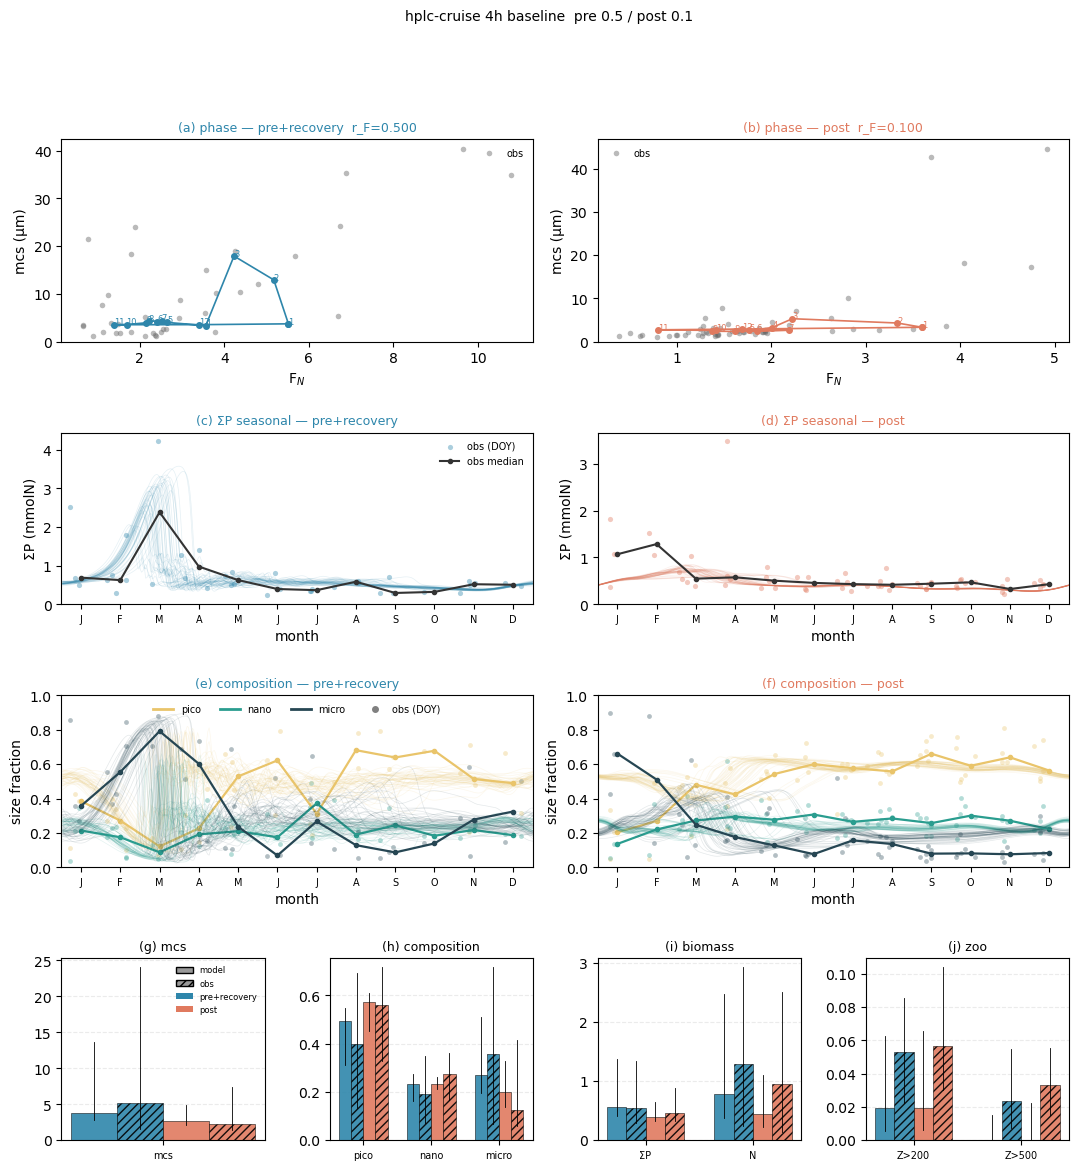

In [59]:
SEL = ('hplc', 4)     # ← cycle me: ('all' or 'hplc', 2/3/4) — must exist in RUNS
runs = RUNS[SEL]; FISH = {'pre+recovery':0.5,'post':0.1}; ERAS = ['pre+recovery','post']
PICKLES = [f"{SEL[0]}-cruise {SEL[1]}h baseline  pre 0.5 / post 0.1"]; PICKLE_IDX = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()

In [60]:
import numpy as np, seasonal_scan_harness as ssh
SELECT = 'base 0.5/0.5/0'      # ← config to load into the overview
FISH={'pre+recovery':0.5,'post':0.1}; ERAS=['pre+recovery','post']
MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
spec=ssh.allometry('maranon_ward'); OBS=ssh.build_obs_targets(ERAS)
FORC=ssh.build_forcings(ERAS, hplc_coincident=False)          # committed baseline (all-cruise)
CFG={'base 0.5/0.5/0':(0.5,0.5),'0.5/0.25/0.25':(0.5,0.25),'0.5/0/0.5':(0.5,0.0),'1.0/0/0':(1.0,0.0)}  # (frac_D, frac_export); N = remainder
def run(g,fD,fX):
    return ssh.run_one(spec,FORC[g],fish_rate=FISH[g],years=60,spinup=15,mP=0.0015,m_Z=0.10,
        grazing={'KsZ':0.23,'sigma_log':0.20},
        iv_overrides={'GrazingRouter':{'gge':0.31},'DetritusSink':{'w_sink':5.0},
                      'ZooQuadMortality':{'frac_D':fD,'frac_export':fX}},
        n_harmonics=3,return_traj=True)[1]
def clim(r,k):
    keep=r['t']>=15*365; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365),'right')+1,1,12); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in range(1,13)])
def fit(r,g):
    k=r['t']>=15*365; mv={m:np.nanmean(r[m][k]) for m in TGT}; md={m:np.nanmedian(r[m][k]) for m in TGT}
    def rms(x,ov):
        t=[((x[m]-ov[m])/ov[m])**2 for m in TGT if ov.get(m) and abs(ov[m])>1e-9 and np.isfinite(x[m])]
        return np.sqrt(np.mean(t)) if t else np.nan
    return max(rms(mv,OBS[g]['mean']),rms(md,OBS[g]['med']))
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']; RUNS={}
print(f"Check 1 — zoo quad routing @ baseline | obs med Z inv {od:+.4f}")
print(f"{'config D/X/N':>16}{'fit_pre':>8}{'fit_post':>9}{'post_ΣPmed':>11}{'post_maxP':>10}{'post_bl':>8}{'Zmed_inv':>10}{'post_Nmed':>10}")
for lab,(fD,fX) in CFG.items():
    rp=run('pre+recovery',fD,fX); rq=run('post',fD,fX); RUNS[lab]={'pre+recovery':rp,'post':rq}
    kp,kq=rp['t']>=15*365, rq['t']>=15*365; cz=clim(rq,'sumP')
    print(f"{lab:>16}{fit(rp,'pre+recovery'):>8.3f}{fit(rq,'post'):>9.3f}{np.nanmedian(rq['sumP'][kq]):>11.3f}"
          f"{np.nanmax(cz):>10.3f}{MO[int(np.nanargmax(cz))]:>8}"
          f"{np.nanmedian(rq['Z200'][kq])-np.nanmedian(rp['Z200'][kp]):>+10.4f}{np.nanmedian(rq['N'][kq]):>10.3f}")
runs=RUNS[SELECT]; PICKLES=[f"zq {SELECT}"]; PICKLE_IDX=0
print(f"\nloaded '{SELECT}' into `runs` for the overview")

Check 1 — zoo quad routing @ baseline | obs med Z inv +0.0035
    config D/X/N fit_pre fit_post post_ΣPmed post_maxP post_bl  Zmed_inv post_Nmed
  base 0.5/0.5/0   0.228    0.167      0.388     0.956       A   +0.0026     0.508
   0.5/0.25/0.25   0.226    0.164      0.395     0.952       A   +0.0037     0.543
       0.5/0/0.5   0.240    0.161      0.404     0.983       A   +0.0042     0.571
         1.0/0/0   0.234    0.165      0.394     0.958       A   +0.0036     0.541

loaded 'base 0.5/0.5/0' into `runs` for the overview


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_30767/3703357628.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()


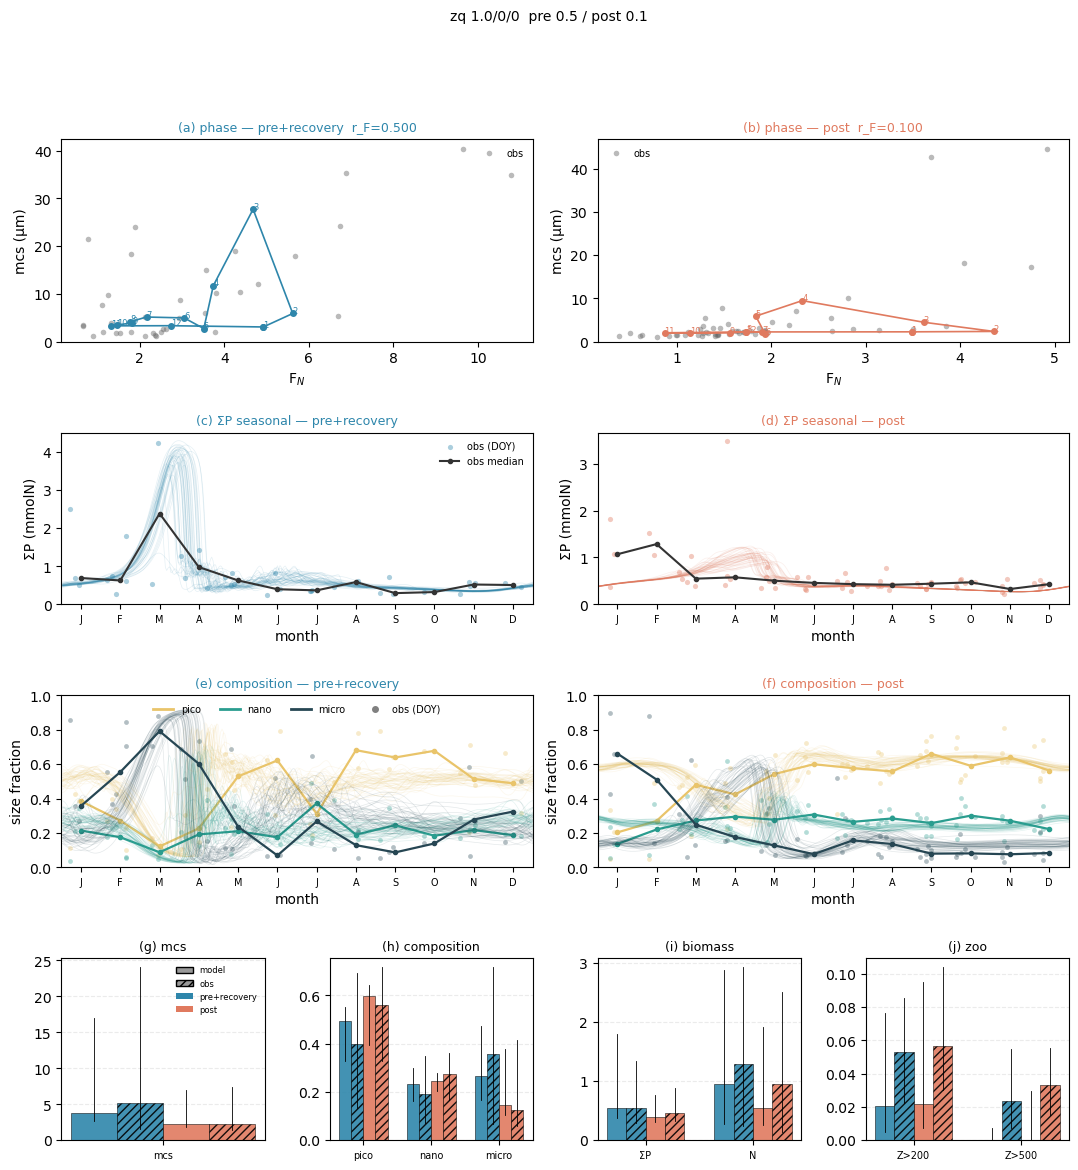

In [65]:
SEL = '1.0/0/0'   # ← cycle: 'base 0.5/0.5/0' | '0.5/0.25/0.25' | '0.5/0/0.5' | '1.0/0/0'
runs = RUNS[SEL]; FISH = {'pre+recovery':0.5,'post':0.1}; ERAS = ['pre+recovery','post']
PICKLES = [f"zq {SEL}  pre 0.5 / post 0.1"]; PICKLE_IDX = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()

In [4]:
# ═══ Fig-4 driver (DISK-CACHED): cycle pickle × ranking, flags filtered ══════
import importlib, pickle, os, numpy as np, pandas as pd, seasonal_scan_harness as ssh

PICKLES = ['seasonal_rF_sweep_hplc3h_2026-06-27.pkl',
           'seasonal_rF_sweep_all3h_2026-06-27.pkl']
PICKLE_IDX   = 0          # ← which file
RANK_IDX     = 0          # ← which pair within the filtered ranking
DROP_FLAGGED = True       # drop pairs with any record flag
REQUIRE_ZDIR = True       # keep only post>pre Z200
PREWARM      = True       # precompute every run in the shortlist now → browsing is instant
PERSIST      = True       # save/restore inspected trajectories to disk (survives kernel restart)
N_HARM       = 3          # MUST match the scan launch
TRAJ_CACHE   = 'traj_cache.pkl'   # NB delete this if you regenerate a scan pickle under the same name

FLAG_KEY = {'X':'collapse / NaN-terminated', 'N':'N runaway (>100)',
            'c':'coexistence loss (a size class ~vanishes)', 'n':'Nano over obs (>+15%)',
            'm':'Micro short of obs (<−15%)', 'b':'ΣP bloom > ±1 month from obs'}

try: _RES_CACHE, _RUN_CACHE                       # persist across re-runs of this cell
except NameError: _RES_CACHE, _RUN_CACHE = {}, {}
if PERSIST and os.path.exists(TRAJ_CACHE) and not _RUN_CACHE:    # restore inspected runs once per kernel
    try:
        with open(TRAJ_CACHE,'rb') as fh: _RUN_CACHE.update(pickle.load(fh))
        print(f"restored {len(_RUN_CACHE)} cached trajectories from {TRAJ_CACHE}")
    except Exception as e:
        print(f"(traj cache load skipped: {e})")
_DIRTY = {'f': False}
def _save_traj_cache():
    if PERSIST and _DIRTY['f']:
        with open(TRAJ_CACHE,'wb') as fh: pickle.dump(_RUN_CACHE, fh)
        _DIRTY['f'] = False

SPEC = ssh.allometry('maranon_ward')

def _rank(path):
    res = ssh.load_results(path); OBS = res.obs; GR = ['pre+recovery', 'post']
    om  = ssh.build_obs_monthly(GR, forcing_complete=True)
    TGT = ['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR = 0.15,100.,0.02,1e-6
    obb = {g: (int(np.nanargmax(om[g].dropna(subset=['sumP']).groupby('mo')['sumP']
                    .median().reindex(range(1,13)).values)+1) if om[g]['sumP'].notna().any() else np.nan) for g in GR}
    def csc(r):
        g=r['group']
        def rms(get,ov):
            t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
            return float(np.sqrt(np.mean(t))) if t else np.nan
        return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']), rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
    def bmo(r):
        c=np.asarray(r.get('clim_sumP',[np.nan]*12),float); return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
    def flg(r):
        g=r['group']; omn=OBS[g]['mean']; f=''
        if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
        if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
        cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in ('pico','nano','micro')]
        if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
        if omn.get('nano')  and np.isfinite(r.get('nano',  np.nan)) and r['nano'] >omn['nano'] *(1+CTOL): f+='n'
        if omn.get('micro') and np.isfinite(r.get('micro', np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
        bm=bmo(r); ob=obb[g]
        if not(np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob)<=1): f+='b'
        return f
    A=pd.DataFrame([dict(group=r['group'],fish=r['fish'],score=csc(r),Z200=r.get('Z200',np.nan),
                         flag=flg(r),bloom=bmo(r)) for r in res.records])
    pre,post=A[A.group=='pre+recovery'],A[A.group=='post']; J=[]
    for _,p in pre.iterrows():
        for _,q in post.iterrows():
            if q.fish>p.fish: continue
            J.append(dict(pre_rF=p.fish,post_rF=q.fish,joint=float(np.nanmax([p.score,q.score])),
                          pre_fl=p['flag'] or '·',post_fl=q['flag'] or '·',Zdir=bool(q.Z200-p.Z200>0),Z200_inv=q.Z200-p.Z200))
    return res, A, pd.DataFrame(J)

def _get(path):
    if path not in _RES_CACHE: _RES_CACHE[path]=_rank(path)
    return _RES_CACHE[path]
def _run_cached(path,group,fish):
    key=(path,group,round(float(fish),6),N_HARM)
    if key not in _RUN_CACHE:
        res=_get(path)[0]
        _RUN_CACHE[key]=ssh.run_one(SPEC,res.forcings[group],fish_rate=float(fish),years=60,spinup=15,
                                    mP=0.0015,m_Z=0.10,grazing={'KsZ':0.23,'sigma_log':0.20},
                                    iv_overrides={'GrazingRouter':{'gge':0.31}},n_harmonics=N_HARM,return_traj=True)
        _DIRTY['f']=True
    return _RUN_CACHE[key]

PATH=PICKLES[PICKLE_IDX]; res,A,J=_get(PATH)
sel=J.copy()
if DROP_FLAGGED: sel=sel[(sel.pre_fl=='·')&(sel.post_fl=='·')]
if REQUIRE_ZDIR: sel=sel[sel.Zdir]
sel=sel.sort_values('joint').reset_index(drop=True)
print(f"pickle[{PICKLE_IDX}] {PATH}  | filtered pairs: {len(sel)} (DROP_FLAGGED={DROP_FLAGGED}, REQUIRE_ZDIR={REQUIRE_ZDIR})")
if len(sel)==0:
    print("  !! none survive — falling back to UNFILTERED joint ranking"); sel=J.sort_values('joint').reset_index(drop=True)
print("flag key: " + " | ".join(f"{k}={v}" for k,v in FLAG_KEY.items()))
print(sel.head(10).round(3).to_string())

if PREWARM:
    todo={('pre+recovery',round(float(r.pre_rF),6)) for _,r in sel.iterrows()} | \
         {('post',round(float(r.post_rF),6)) for _,r in sel.iterrows()}
    new=[(g,f) for (g,f) in todo if (PATH,g,f,N_HARM) not in _RUN_CACHE]
    if new:
        print(f"prewarming {len(new)} uncached runs ...",flush=True)
        for g,f in new: _run_cached(PATH,g,f)
        _save_traj_cache()                         # one disk write after the batch

row=sel.iloc[min(RANK_IDX,len(sel)-1)]; PF,QF=float(row.pre_rF),float(row.post_rF)
print(f"\n>>> RANK_IDX={RANK_IDX}:  pre_rF={PF:.3f}  post_rF={QF:.3f}  joint={row.joint:.3f}  "
      f"Z200_inv={row.Z200_inv:+.4f}  flags[{row.pre_fl}/{row.post_fl}]")
ERAS=['pre+recovery','post']; FISH={'pre+recovery':PF,'post':QF}
runs={g:_run_cached(PATH,g,FISH[g])[1] for g in ERAS}
_save_traj_cache()                                 # persist anything new (no-op if all cached)
print(f"cache: {len(_RUN_CACHE)} runs held ({sum(1 for k in _RUN_CACHE if k[0]==PATH)} for this pickle)"
      f"{' | saved to '+TRAJ_CACHE if PERSIST else ''}")

pickle[0] seasonal_rF_sweep_hplc3h_2026-06-27.pkl  | filtered pairs: 7 (DROP_FLAGGED=True, REQUIRE_ZDIR=True)
flag key: X=collapse / NaN-terminated | N=N runaway (>100) | c=coexistence loss (a size class ~vanishes) | n=Nano over obs (>+15%) | m=Micro short of obs (<−15%) | b=ΣP bloom > ±1 month from obs
   pre_rF  post_rF  joint pre_fl post_fl  Zdir  Z200_inv
0   0.562    0.069  0.252      ·       ·  True     0.001
1   0.543    0.069  0.252      ·       ·  True     0.000
2   0.581    0.069  0.252      ·       ·  True     0.001
3   0.562    0.050  0.313      ·       ·  True     0.003
4   0.543    0.050  0.313      ·       ·  True     0.002
5   0.581    0.050  0.313      ·       ·  True     0.002
6   0.600    0.050  0.313      ·       ·  True     0.001
prewarming 6 uncached runs ...

>>> RANK_IDX=0:  pre_rF=0.562  post_rF=0.069  joint=0.252  Z200_inv=+0.0009  flags[·/·]
cache: 6 runs held (6 for this pickle) | saved to traj_cache.pkl


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_30767/3092898766.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]} | pre_rF={FISH['pre+recovery']:.3f} post_rF={FISH['post']:.3f}",fontsize=10); plt.tight_layout(); plt.show()


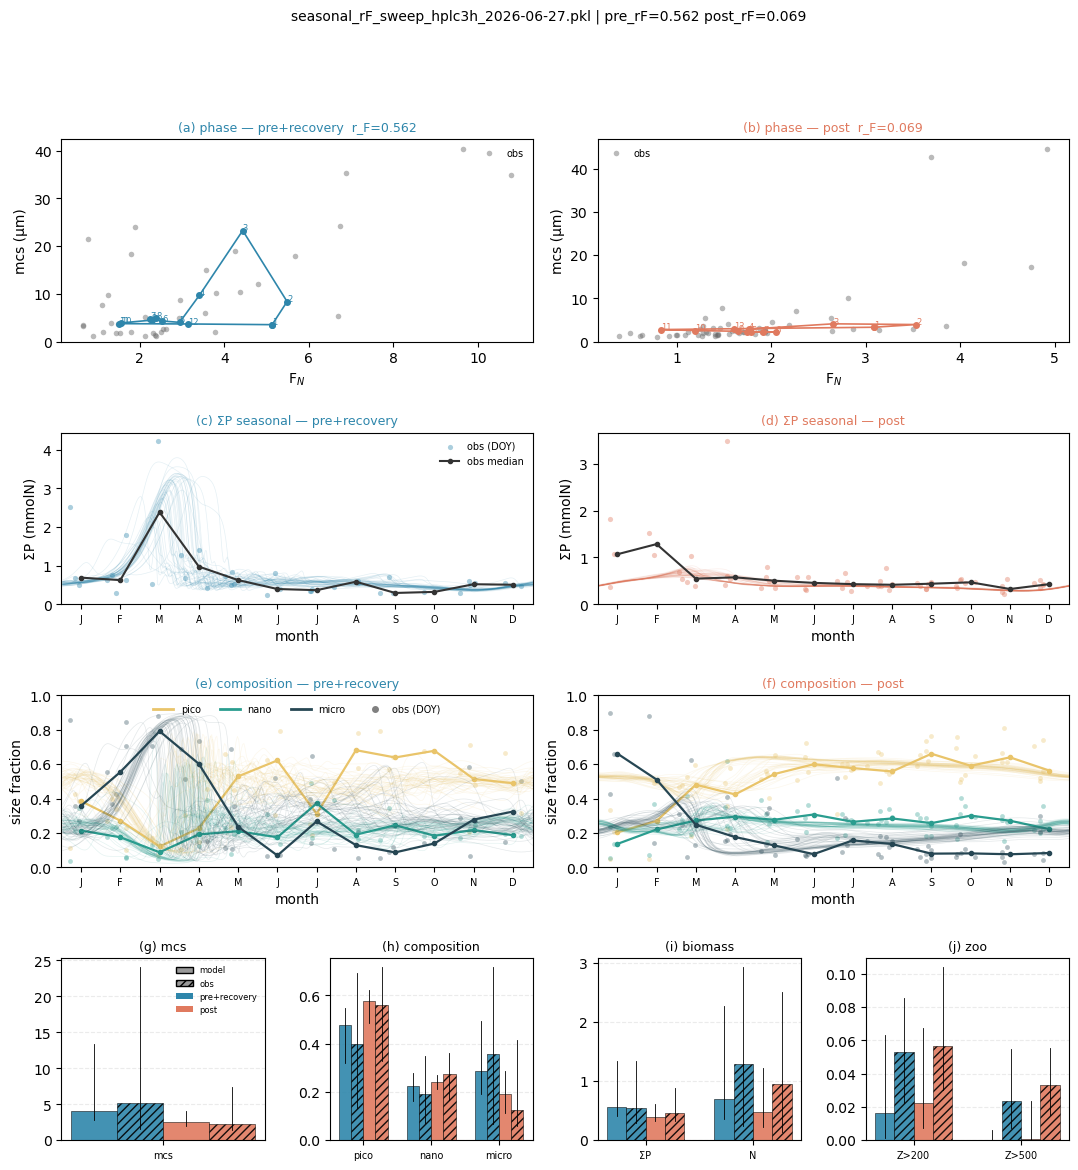

In [7]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(doy): return np.interp(np.asarray(doy,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):                                  # obs x at cruise DOY, mo fallback
    d=df.get(col, pd.Series(np.nan,index=df.index)) if hasattr(df,'get') else df[col]
    return np.where(np.isfinite(d), doy_to_mo(d), df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=0.9,hatch=h,edgecolor='k',lw=0.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=0.6,zorder=4)
import pandas as pd
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,0.85,0.85,0.9],hspace=0.5,wspace=0.32)
# Row0 phase (FN–mcs; no time axis → no DOY)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=0.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
# Row1 ΣP seasonal (obs at doy_hplc)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=0.12,lw=0.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=0.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
# Row2 composition seasonal (obs at doy_hplc)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=0.12,lw=0.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=0.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
# Row3 bars
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-0.5*W,('post','m'):0.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=0.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]} | pre_rF={FISH['pre+recovery']:.3f} post_rF={FISH['post']:.3f}",fontsize=10); plt.tight_layout(); plt.show()


######################################################################
## TOP joint: pre_rF=0.524 post_rF=0.107
######################################################################

[TOP joint | pre+recovery | r_F=0.524]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs            6.1      9.94      3.83      5.14   -0.39   -0.26
pico          0.46     0.418      0.49     0.399   +0.10   +0.23
nano         0.226      0.21      0.23     0.193   +0.08   +0.19
micro        0.314     0.372     0.274     0.357   -0.16   -0.23
sumP         0.719     0.748     0.543      0.55   -0.04   -0.01
N             1.14      1.51     0.789      1.29   -0.24   -0.39
PP           0.158     0.542     0.135      0.28   -0.71   -0.52
Export        2.28      3.52      2.15      2.64   -0.35   -0.19
Z200        0.0315    0.0533    0.0168     0.053   -0.41   -0.68
Z500       0.00593    0.0302   0.00013    0.0235   -0.80   -0.99
score   mean=0.218  med=0.228

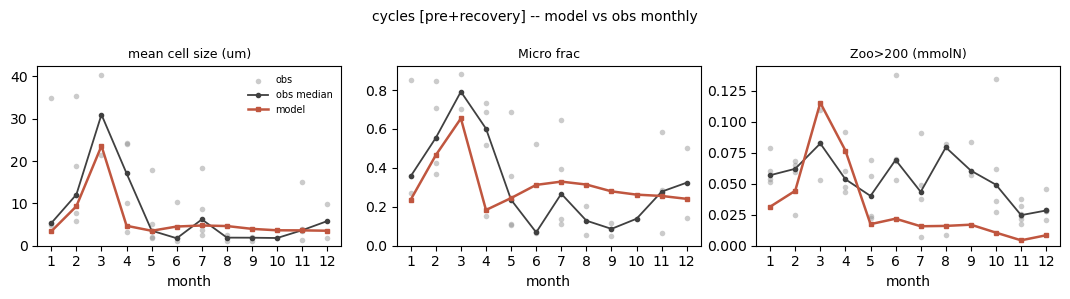

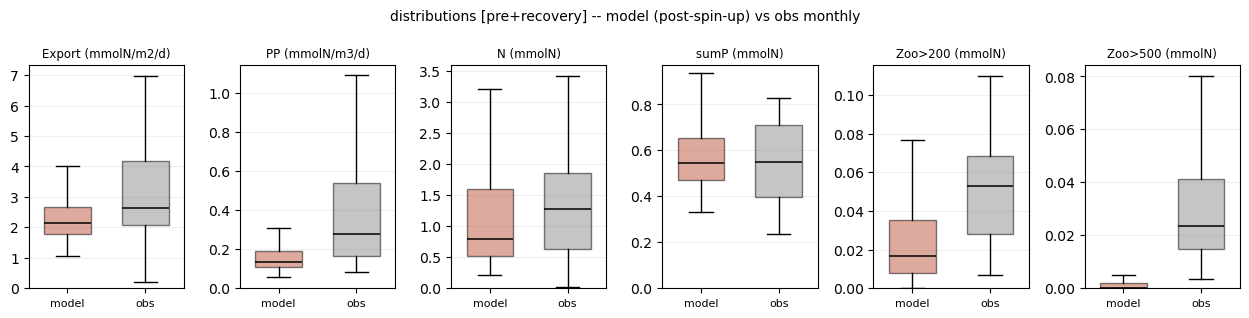

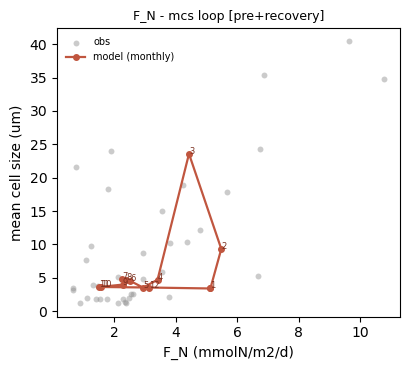


[TOP joint | post | r_F=0.107]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.81      4.67      2.47      2.32   -0.40   +0.07
pico         0.565     0.542     0.585     0.562   +0.04   +0.04
nano         0.242     0.267     0.238     0.272   -0.10   -0.12
micro        0.193     0.191     0.179     0.124   +0.01   +0.44
sumP         0.423     0.581     0.389     0.459   -0.27   -0.15
N            0.553      1.23     0.456     0.959   -0.55   -0.52
PP             0.1     0.324    0.0943     0.202   -0.69   -0.53
Export         1.8      2.67      1.78      2.17   -0.32   -0.18
Z200        0.0272     0.066    0.0195    0.0566   -0.59   -0.66
Z500       0.00515    0.0371  0.000145    0.0334   -0.86   -1.00
score   mean=0.206  med=0.233  joint(max)=0.233   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.079 cv_sumP=0.26
        floor   minP=0.0000  minZ=0.0000   (post-spin-up min o

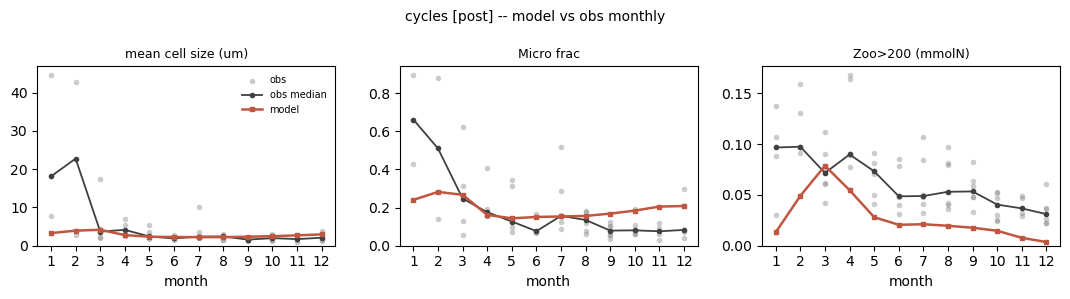

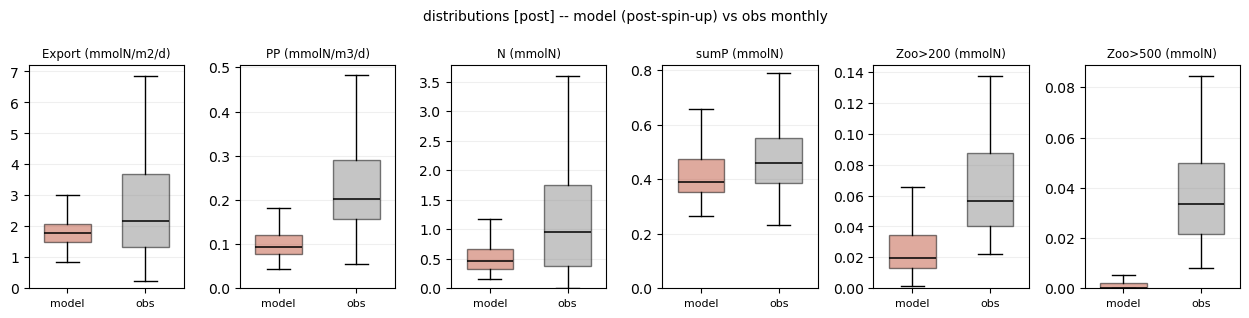

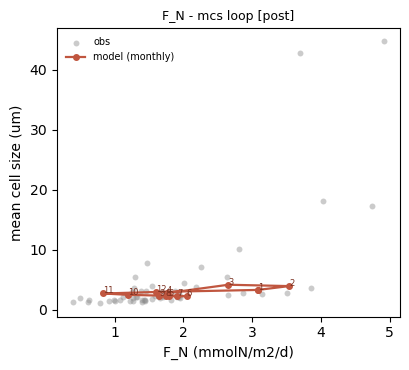


######################################################################
## TOP Zdir-ok: pre_rF=0.562 post_rF=0.069
######################################################################

[TOP Zdir-ok | pre+recovery | r_F=0.562]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.62      9.94      3.89      5.14   -0.33   -0.24
pico         0.448     0.418     0.485     0.399   +0.07   +0.21
nano         0.222      0.21      0.23     0.193   +0.06   +0.19
micro         0.33     0.372     0.278     0.357   -0.11   -0.22
sumP         0.747     0.748     0.546      0.55   -0.00   -0.01
N             1.11      1.51     0.741      1.29   -0.27   -0.42
PP           0.156     0.542      0.13      0.28   -0.71   -0.54
Export        2.21      3.52      2.07      2.64   -0.37   -0.21
Z200        0.0296    0.0533    0.0151     0.053   -0.44   -0.72
Z500       0.00336    0.0302   3.6e-05    0.0235   -0.89   -1.00
score   mean=0.182  med=0

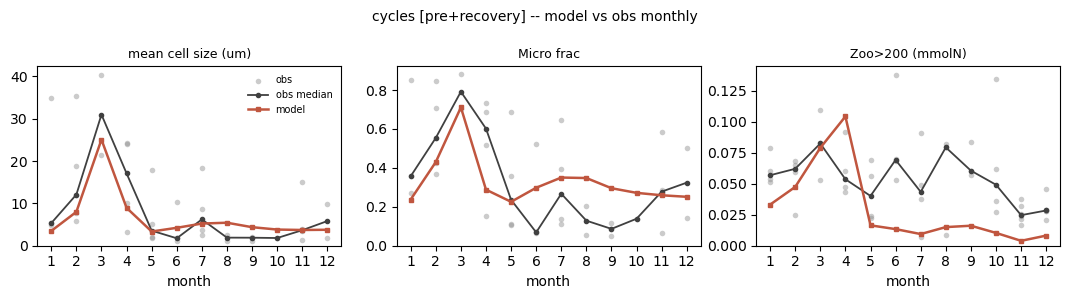

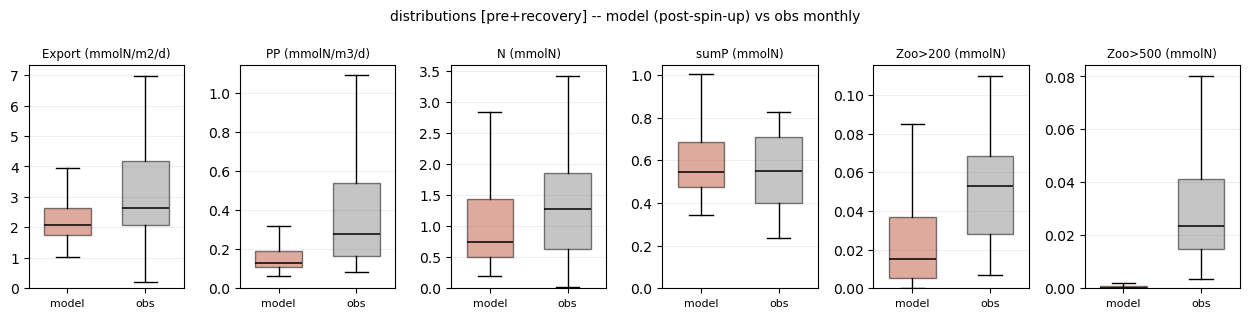

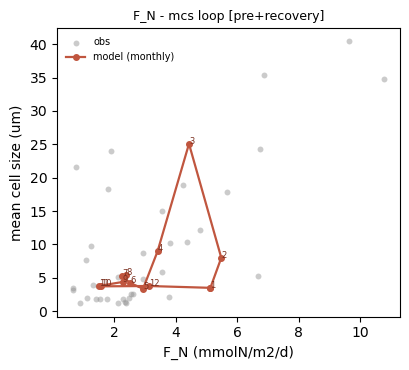


[TOP Zdir-ok | post | r_F=0.069]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.81      4.67      2.57      2.32   -0.40   +0.11
pico         0.564     0.542      0.58     0.562   +0.04   +0.03
nano         0.242     0.267      0.24     0.272   -0.09   -0.12
micro        0.194     0.191     0.188     0.124   +0.02   +0.52
sumP         0.426     0.581     0.389     0.459   -0.27   -0.15
N            0.565      1.23     0.466     0.959   -0.54   -0.51
PP           0.101     0.324    0.0955     0.202   -0.69   -0.53
Export        1.83      2.67      1.81      2.17   -0.31   -0.17
Z200        0.0305     0.066    0.0225    0.0566   -0.54   -0.60
Z500       0.00589    0.0371  0.000465    0.0334   -0.84   -0.99
score   mean=0.206  med=0.271  joint(max)=0.271   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200_peak=0.086 cv_sumP=0.26
        floor   minP=0.0000  minZ=0.0000   (post-spin-up min

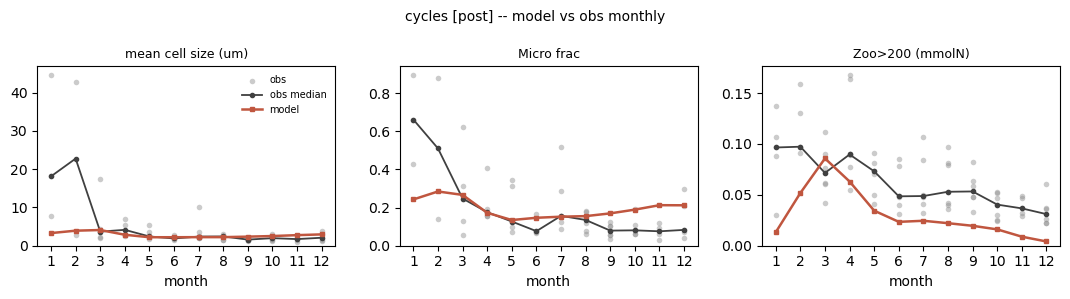

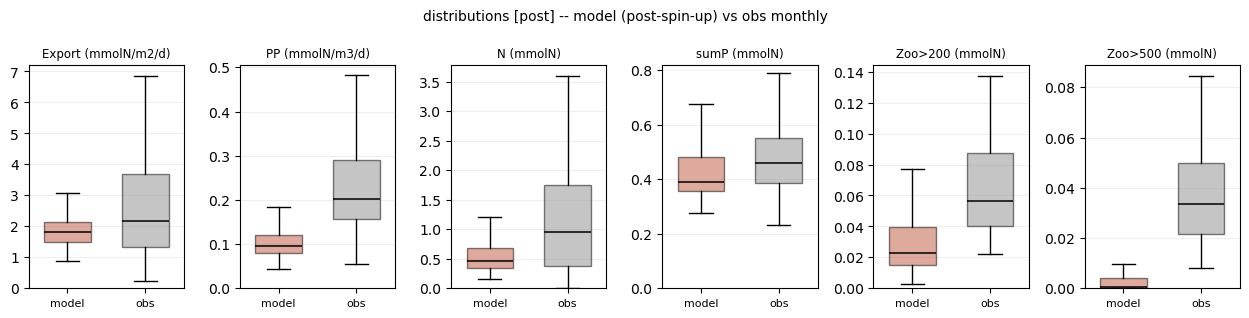

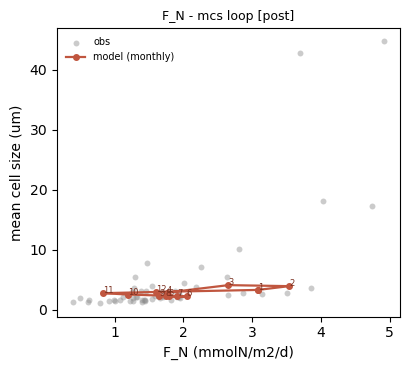


######################################################################
## TOP clean & Zdir: pre_rF=0.562 post_rF=0.069
######################################################################

[TOP clean & Zdir | pre+recovery | r_F=0.562]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.62      9.94      3.89      5.14   -0.33   -0.24
pico         0.448     0.418     0.485     0.399   +0.07   +0.21
nano         0.222      0.21      0.23     0.193   +0.06   +0.19
micro         0.33     0.372     0.278     0.357   -0.11   -0.22
sumP         0.747     0.748     0.546      0.55   -0.00   -0.01
N             1.11      1.51     0.741      1.29   -0.27   -0.42
PP           0.156     0.542      0.13      0.28   -0.71   -0.54
Export        2.21      3.52      2.07      2.64   -0.37   -0.21
Z200        0.0296    0.0533    0.0151     0.053   -0.44   -0.72
Z500       0.00336    0.0302   3.6e-05    0.0235   -0.89   -1.00
score   mean=0.

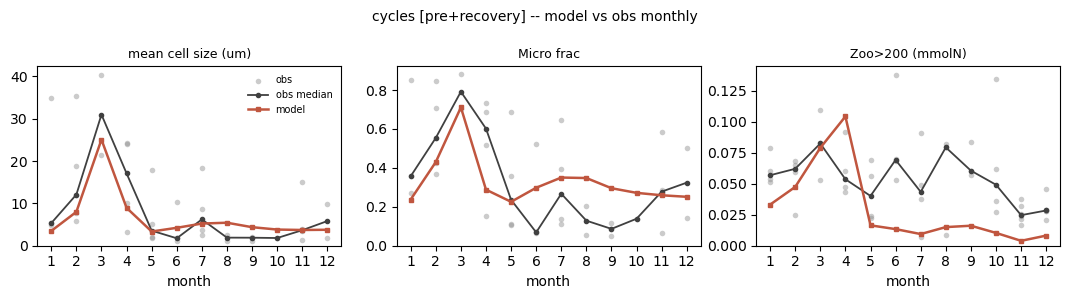

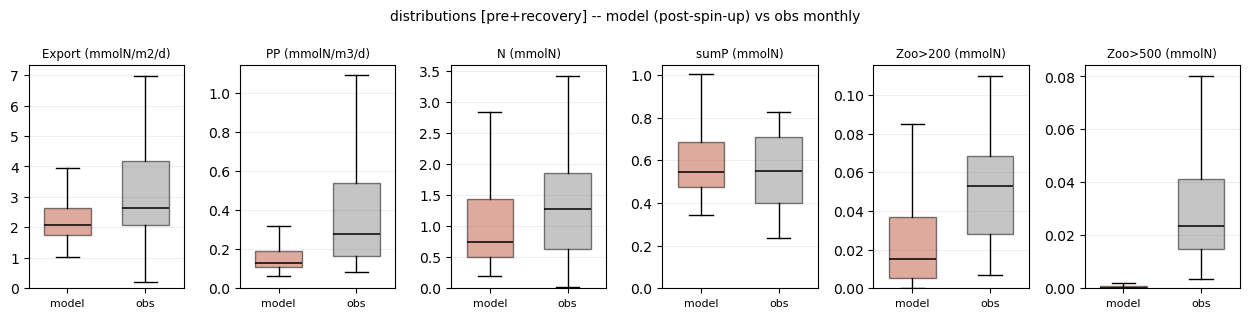

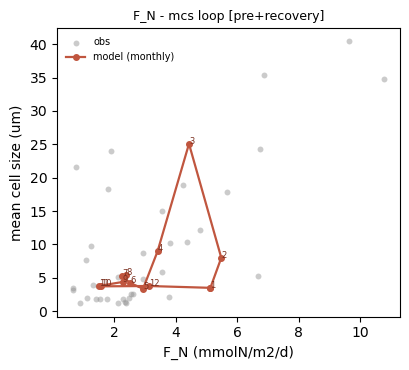


[TOP clean & Zdir | post | r_F=0.069]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.81      4.67      2.57      2.32   -0.40   +0.11
pico         0.564     0.542      0.58     0.562   +0.04   +0.03
nano         0.242     0.267      0.24     0.272   -0.09   -0.12
micro        0.194     0.191     0.188     0.124   +0.02   +0.52
sumP         0.426     0.581     0.389     0.459   -0.27   -0.15
N            0.565      1.23     0.466     0.959   -0.54   -0.51
PP           0.101     0.324    0.0955     0.202   -0.69   -0.53
Export        1.83      2.67      1.81      2.17   -0.31   -0.17
Z200        0.0305     0.066    0.0225    0.0566   -0.54   -0.60
Z500       0.00589    0.0371  0.000465    0.0334   -0.84   -0.99
score   mean=0.206  med=0.271  joint(max)=0.271   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200_peak=0.086 cv_sumP=0.26
        floor   minP=0.0000  minZ=0.0000   (post-spin-u

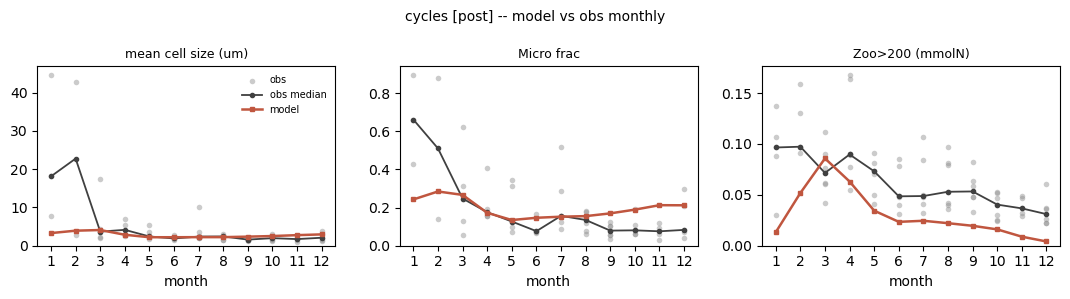

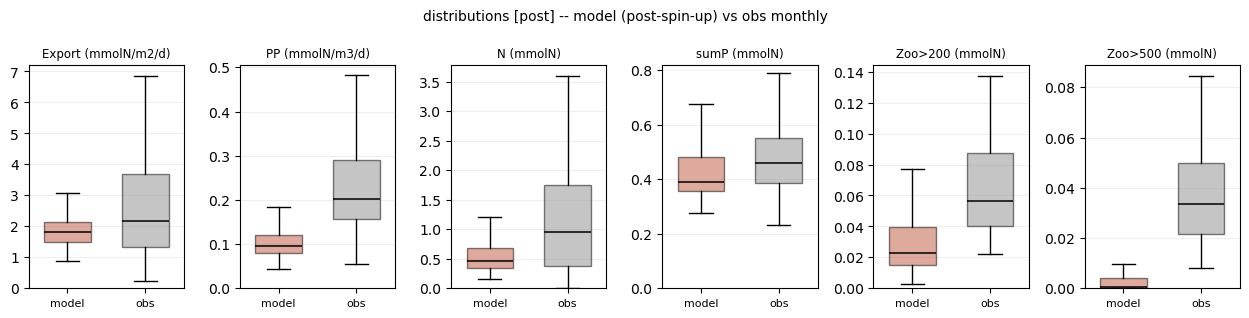

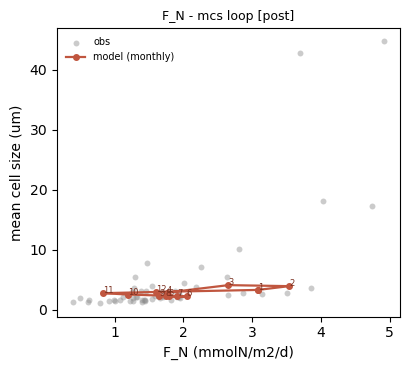


######################################################################
## committed 0.5/0.1: pre_rF=0.500 post_rF=0.100
######################################################################

[committed 0.5/0.1 | pre+recovery | r_F=0.500]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           5.52      9.94      3.81      5.14   -0.44   -0.26
pico         0.468     0.418      0.49     0.399   +0.12   +0.23
nano         0.229      0.21     0.232     0.193   +0.09   +0.20
micro        0.303     0.372     0.271     0.357   -0.19   -0.24
sumP         0.682     0.748     0.549      0.55   -0.09   -0.00
N             1.21      1.51     0.843      1.29   -0.20   -0.34
PP            0.16     0.542     0.138      0.28   -0.70   -0.51
Export        2.34      3.52      2.18      2.64   -0.34   -0.17
Z200        0.0335    0.0533    0.0184     0.053   -0.37   -0.65
Z500       0.00881    0.0302  0.000389    0.0235   -0.71   -0.98
score   mean=

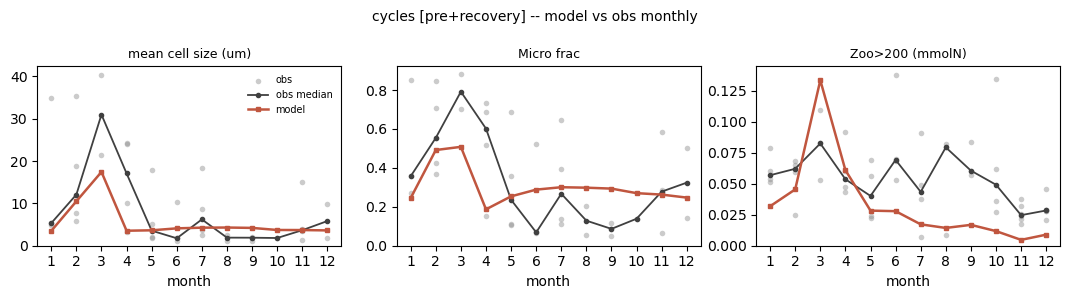

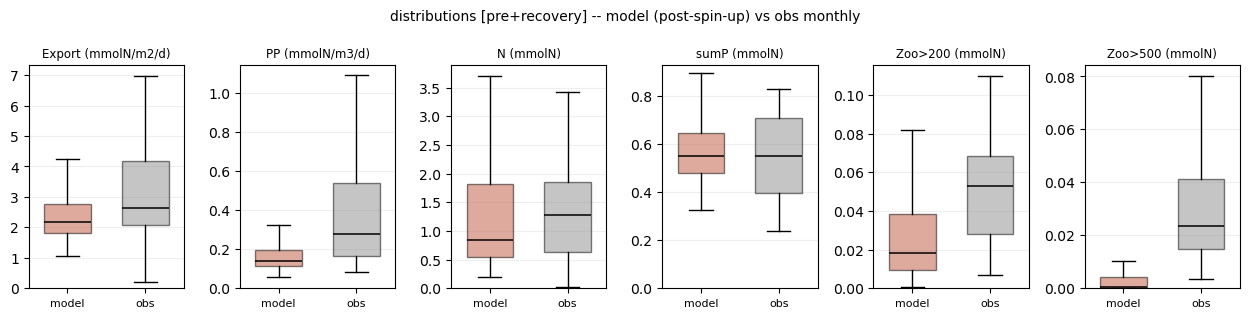

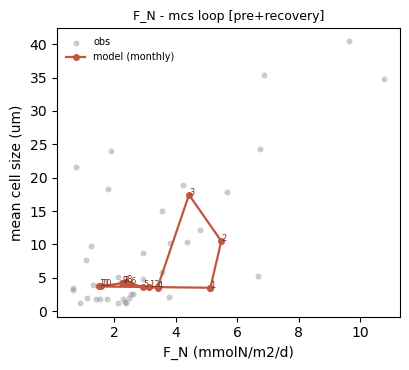


[committed 0.5/0.1 | post | r_F=0.100]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.86      4.67      2.53      2.32   -0.39   +0.09
pico         0.563     0.542     0.583     0.562   +0.04   +0.04
nano          0.24     0.267     0.237     0.272   -0.10   -0.13
micro        0.197     0.191     0.184     0.124   +0.03   +0.49
sumP         0.427     0.581      0.39     0.459   -0.27   -0.15
N            0.555      1.23     0.456     0.959   -0.55   -0.52
PP             0.1     0.324    0.0943     0.202   -0.69   -0.53
Export        1.81      2.67      1.77      2.17   -0.32   -0.18
Z200        0.0276     0.066    0.0199    0.0566   -0.58   -0.65
Z500       0.00526    0.0371   0.00015    0.0334   -0.86   -1.00
score   mean=0.202  med=0.256  joint(max)=0.256   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.01 Z200_peak=0.077 cv_sumP=0.27
        floor   minP=0.0000  minZ=0.0000   (post-spin-

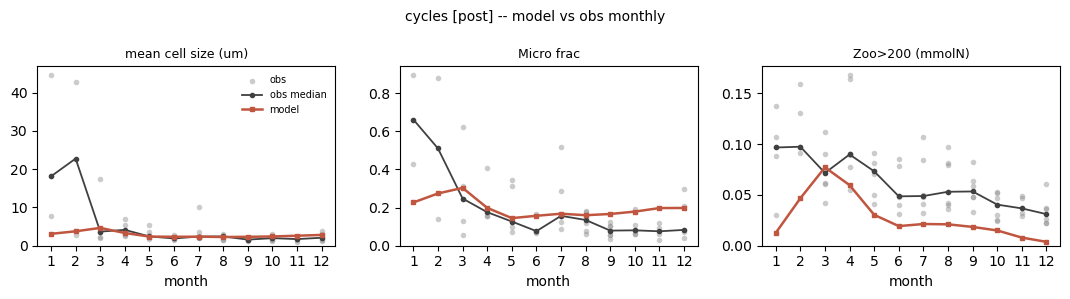

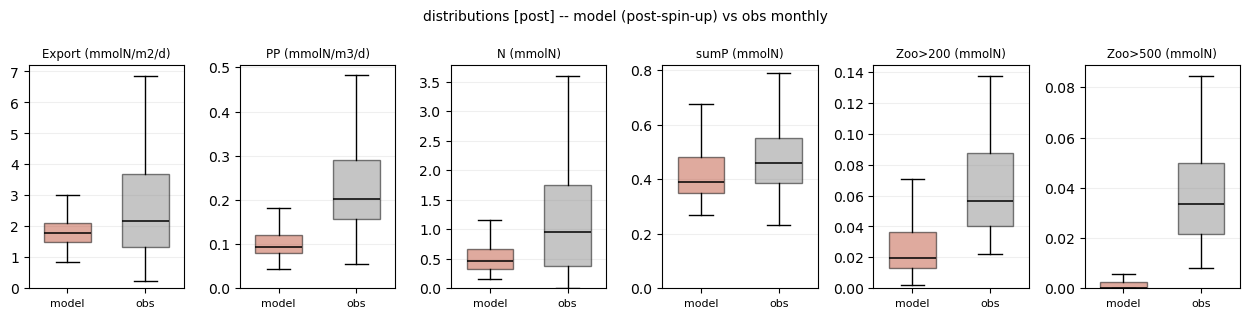

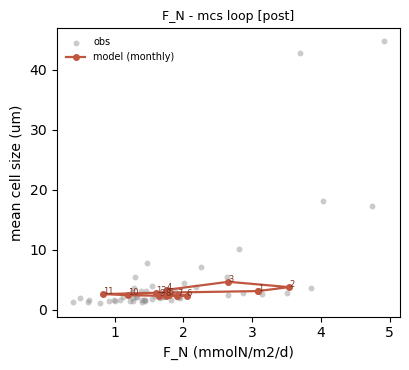

In [6]:
import seasonal_diagnostics as sd, importlib; importlib.reload(sd)
N_HARM=3; spec=ssh.allometry('maranon_ward'); FORC=res.forcings; OBS_T=res.obs
OBS_M=ssh.build_obs_monthly(['pre+recovery','post'],forcing_complete=True)
def _run(g,fish): return ssh.run_one(spec,FORC[g],fish_rate=float(fish),years=60,spinup=15,mP=0.0015,m_Z=0.10,
    grazing={'KsZ':0.23,'sigma_log':0.20},iv_overrides={'GrazingRouter':{'gge':0.31}},n_harmonics=N_HARM,return_traj=True)
def _fp(df): return (float(df.iloc[0].pre_rF),float(df.iloc[0].post_rF)) if len(df) else (np.nan,np.nan)
Jz=J[J.Z200_inv>0].sort_values('joint'); Jcz=J[(J.pre_fl=='·')&(J.post_fl=='·')&(J.Z200_inv>0)].sort_values('joint')
CANDS=[('TOP joint',*_fp(J.sort_values('joint'))),('TOP Zdir-ok',*_fp(Jz)),('TOP clean & Zdir',*_fp(Jcz)),('committed 0.5/0.1',0.5,0.1)]
for tag,pf,qf in CANDS:
    if not(np.isfinite(pf) and np.isfinite(qf)): print(f"\n### {tag}: n/a"); continue
    print('\n'+'#'*70+f"\n## {tag}: pre_rF={pf:.3f} post_rF={qf:.3f}\n"+'#'*70)
    for g,fish in [('pre+recovery',pf),('post',qf)]:
        clim,r=_run(g,fish); sd.diagnose(clim,r,g,spinup=15,obs_targets=OBS_T,obs_monthly=OBS_M,title=f"\n[{tag} | {g} | r_F={fish:.3f}]")